In [1]:
#========================================================================
# Name: plot_fig_6_7_8_S*_wrf_vs_obs_dsd_properties.ipynb
# Author: McKenna W. Stanford
# Author Contact: mckenna.stanford@pnnl.gov
#
# Utility: Reads in CTH variables from derived files and pulls in the
# corresponding derived gamma dsd properties. Then limits the simulated
# dataset to the ridgeline, CTTs at least shallow enough to be considered
# congestus (i.e., > -20 deg C), and limits points in general to be above 0
# deg C. Pulls in obesrvational in-situ data and then plots all figures
# for the relevant analysis.
#========================================================================

In [1]:
#===============================
# Imports
#===============================
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob 
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import datetime
import matplotlib.colors as colors
import matplotlib as mpl
from pytz import utc
from matplotlib.lines import Line2D
import pickle
from scipy.spatial import cKDTree
import pandas as pd
import os

import dask
from distributed import Client, LocalCluster
from dask import delayed, compute
import dask.array as da

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.img_tiles as cimgt
import shapely.geometry as sgeom
import matplotlib.patheffects as path_effects

import scipy
import warnings
warnings.filterwarnings("ignore")
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

plt.rcParams['text.usetex'] = True

/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


# Start Dask configuration if still need to concetanate simulation gamma distribution files limited to congestus profiles (skip if reading in pickel file produced below)

In [3]:
dask.config.config["distributed"]["dashboard"]["link"] = "{JUPYTERHUB_SERVICE_PREFIX}proxy/{host}:{port}/status" 

In [4]:
cluster = LocalCluster(n_workers=80,threads_per_worker=1,memory_limit='5GB')#,dashboard_address=':8787')
client = Client(cluster)

Task exception was never retrieved
future: <Task finished name='Task-215728' coro=<Client._gather.<locals>.wait() done, defined at /global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/distributed/client.py:2396> exception=AllExit()>
Traceback (most recent call last):
  File "/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/distributed/client.py", line 2405, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-215732' coro=<Client._gather.<locals>.wait() done, defined at /global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/distributed/client.py:2396> exception=AllExit()>
Traceback (most recent call last):
  File "/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/distributed/client.py", line 2405, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-2

In [5]:
cluster

LocalCluster(fadf7beb, 'tcp://127.0.0.1:45937', workers=80, threads=80, memory=372.53 GiB)

In [6]:
def suppress_warnings():
    import warnings
    warnings.filterwarnings("ignore", message=".*All-NaN axis encountered*", category=UserWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)

client.run(suppress_warnings)

{'tcp://127.0.0.1:32895': None,
 'tcp://127.0.0.1:32919': None,
 'tcp://127.0.0.1:33053': None,
 'tcp://127.0.0.1:33121': None,
 'tcp://127.0.0.1:33235': None,
 'tcp://127.0.0.1:33259': None,
 'tcp://127.0.0.1:33291': None,
 'tcp://127.0.0.1:33489': None,
 'tcp://127.0.0.1:33505': None,
 'tcp://127.0.0.1:34143': None,
 'tcp://127.0.0.1:34547': None,
 'tcp://127.0.0.1:34981': None,
 'tcp://127.0.0.1:35377': None,
 'tcp://127.0.0.1:35583': None,
 'tcp://127.0.0.1:35891': None,
 'tcp://127.0.0.1:36067': None,
 'tcp://127.0.0.1:36105': None,
 'tcp://127.0.0.1:36169': None,
 'tcp://127.0.0.1:36183': None,
 'tcp://127.0.0.1:36277': None,
 'tcp://127.0.0.1:36363': None,
 'tcp://127.0.0.1:36467': None,
 'tcp://127.0.0.1:36479': None,
 'tcp://127.0.0.1:36573': None,
 'tcp://127.0.0.1:37559': None,
 'tcp://127.0.0.1:37797': None,
 'tcp://127.0.0.1:38285': None,
 'tcp://127.0.0.1:38321': None,
 'tcp://127.0.0.1:38393': None,
 'tcp://127.0.0.1:38493': None,
 'tcp://127.0.0.1:38547': None,
 'tcp://

In [3]:
# If True, reads in and concatenates all congestus dsd files from simulation. Otherwise, we read it in below.
if False:
   # %%time
    print('Step 1')
    # Step 1: List .npz files
    #npz_files = sorted(glob.glob('/pscratch/sd/m/mckenna/cacti/wrf/temp_cong_dsd_params/cong_dsd_params_*00.npz'))
    npz_files = sorted(glob.glob('/pscratch/sd/m/mckenna/cacti/wrf/temp_cong_dsd_params/cong_dsd_params_*_v2.npz'))
    print('Step 2')
    # Step 2: Get all keys by inspecting the first file
    with np.load(npz_files[0]) as sample:
        all_keys = list(sample.keys())
    print('Step 3')
    
    # Step 3: Delayed function to load a single file
    @delayed
    def load_npz_var(filepath, varname):
        with np.load(filepath) as data:
            return data[varname]
    print('Step 4')
    # Step 4: For each variable, collect delayed arrays and concatenate
    def extract_and_concat(varname, file_list):
        delayed_arrays = [load_npz_var(f, varname) for f in file_list]
        return delayed(np.concatenate)(delayed_arrays)
    print('Step 5')
    # Step 5: Build delayed concatenation for each variable
    concatenated_vars = {
        k: extract_and_concat(k, npz_files) for k in all_keys
    }
    print('Step 6')
    # Step 6: Compute in parallel
    computed_values = compute(*concatenated_vars.values())
    print('Step 7')
    
    # Step 7: Reconstruct dictionary
    wrf_dict = dict(zip(concatenated_vars.keys(), computed_values))

    with open('wrf_dsd_props_cu_only.p', 'wb') as f:
        pickle.dump(wrf_dict, f)

In [4]:
# Option to limit only to flight dates
if False:

    # Your observed dates
    obs_dates = set(['20181104', '20181106', '20181110', '20181112', '20181116', 
                     '20181117', '20181120', '20181121', '20181122', '20181124', 
                     '20181125', '20181128', '20181129', '20181203', '20181204', '20181207'])
    
    # Step 1: List .npz files BUT filter to only observed flight dates
    all_npz_files = sorted(glob.glob('/pscratch/sd/m/mckenna/cacti/wrf/temp_cong_dsd_params/cong_dsd_params_*00.npz'))
    
    # Extract date from filename and filter
    # Filename format: cong_dsd_params_20181017_03:15:00.npz
    npz_files = [f for f in all_npz_files if os.path.basename(f).split('_')[3] in obs_dates]
    
    print(f'Total WRF files available: {len(all_npz_files)}')
    print(f'WRF files matching flight dates: {len(npz_files)}')
    print('Matched dates:', sorted(set(os.path.basename(f).split('_')[3] for f in npz_files)))


    print('Step 2')
    # Step 2: Get all keys by inspecting the first file
    with np.load(npz_files[0]) as sample:
        all_keys = list(sample.keys())
    print('Step 3')
    
    # Step 3: Delayed function to load a single file
    @delayed
    def load_npz_var(filepath, varname):
        with np.load(filepath) as data:
            return data[varname]
    print('Step 4')
    # Step 4: For each variable, collect delayed arrays and concatenate
    def extract_and_concat(varname, file_list):
        delayed_arrays = [load_npz_var(f, varname) for f in file_list]
        return delayed(np.concatenate)(delayed_arrays)
    print('Step 5')
    # Step 5: Build delayed concatenation for each variable
    concatenated_vars = {
        k: extract_and_concat(k, npz_files) for k in all_keys
    }
    print('Step 6')
    # Step 6: Compute in parallel
    computed_values = compute(*concatenated_vars.values())
    print('Step 7')
    
    # Step 7: Reconstruct dictionary
    wrf_dict = dict(zip(concatenated_vars.keys(), computed_values))

    with open('wrf_dsd_props_cu_only_date_lim.p', 'wb') as f:
        pickle.dump(wrf_dict, f)

# Load file

In [2]:
#with open('wrf_dsd_props_cu_only_date_lim.p', 'rb') as f: # used for database limited to flight dates
with open('wrf_dsd_props_cu_only.p', 'rb') as f:
    wrf_dict = pickle.load(f)
wrf_dict['N'] = wrf_dict['N']*wrf_dict['rho_air']*1.e-6 # Convert number concentrations from kg^-1 to cm^-3

## Filter simulated points to only include those with CLWC above a threshold (also done for observations below)
### This is to ensure that simulated grid points are "in-cloud", which is inherently what the observed aircraft targeted

In [3]:
filter_clwc_bool = True
clwc_thresh = 1.e-6
clwc_id = np.where(wrf_dict['qc']*wrf_dict['rho_air']*1.e3 > clwc_thresh)[0]
no_clwc_id = np.where(wrf_dict['qc']*wrf_dict['rho_air']*1.e3 <= clwc_thresh)[0]
print(len(clwc_id)/len(wrf_dict['q'])*100.)
print(len(no_clwc_id)/len(wrf_dict['q'])*100.)
if filter_clwc_bool:
    for key,val in wrf_dict.items():
        wrf_dict[key] = val[clwc_id]

72.06006884829233
27.939931151707665


# Read in and process observational dataset

In [4]:
with open('/global/homes/m/mckenna/projdir/cacti/aircraft_in_situ/post/processed_merged_flight_dictionaries.p', 'rb') as f:
    in_obs_dict = pickle.load(f)

In [5]:
#np.shape(in_obs_dict['20181106']['diameter_centers'])
np.shape(in_obs_dict['20181106']['diameter_bounds'])
dD = in_obs_dict['20181106']['diameter_bounds'][:,1] - in_obs_dict['20181106']['diameter_bounds'][:,0]
dlogD = np.log10(in_obs_dict['20181106']['diameter_bounds'][:,1]) - np.log10(in_obs_dict['20181106']['diameter_bounds'][:,0])

In [6]:
all_total_conc = []
all_total_lwc = []
all_conc_gt_100um = []
all_lwc_gt_100um = []
all_temp = []
all_mmd = []
all_D_num = []
all_D_vol = []
all_D_mass = []
all_w = []
all_dN = []
all_dM = []
all_temp = []
all_rh = []
all_time = []
all_alt = []
all_fcdp_lwc = []

dumi=0
for key in in_obs_dict.keys():

    if dumi==0:
        obs_diam = in_obs_dict[key]['diameter_centers']
        obs_dD = in_obs_dict[key]['diameter_bounds'][:,1] - in_obs_dict[key]['diameter_bounds'][:,0]
        obs_dlogD = np.log10(in_obs_dict[key]['diameter_bounds'][:,1]) - np.log10(in_obs_dict[key]['diameter_bounds'][:,0])

    if True:
        tmp_total_conc = in_obs_dict[key]['integrated_total_conc'].copy() # /cm^3
        tmp_total_lwc = in_obs_dict[key]['integrated_lwc'].copy() # g/m^3
        tmp_conc_gt_100um = in_obs_dict[key]['Nd_gt_100um'].copy() # /cm^-3
        tmp_lwc_gt_100um = in_obs_dict[key]['LWC_gt_100um'].copy() # g/m^3
        tmp_temp = in_obs_dict[key]['ambient_temp'].copy() # deg C
        #tmp_temp = in_obs_dict[key]['total_temp'].copy() # deg C
        tmp_rh = in_obs_dict[key]['rh'].copy() # %
        tmp_w = in_obs_dict[key]['vertical_wind_speed'].copy() # m/s
        tmp_mmd = in_obs_dict[key]['mmd'].copy() # um
        tmp_D_num = in_obs_dict[key]['D_num'].copy() # um
        tmp_D_vol = in_obs_dict[key]['D_vol'].copy() # um
        tmp_D_mass = in_obs_dict[key]['D_mass'].copy() # um
        tmp_dN = in_obs_dict[key]['dNdD'].copy() # /cm^3/um
        tmp_dM = in_obs_dict[key]['dMdD'].copy() # g/m^3/um
        tmp_time = in_obs_dict[key]['time_dt'].copy() 
        tmp_alt = in_obs_dict[key]['altitude'].copy() 
        tmp_fcdp_lwc = in_obs_dict[key]['fcdp_lwc'].copy() 
    
    lwc_thresh = 1.e-3
    conc_thresh = 0
    dumid = np.where( (tmp_total_conc > conc_thresh) & (tmp_total_lwc > lwc_thresh) & (tmp_temp > 0.) )
    dumid = dumid[0]
    tmp_total_conc = tmp_total_conc[dumid]
    tmp_total_lwc = tmp_total_lwc[dumid]
    tmp_conc_gt_100um = tmp_conc_gt_100um[dumid]
    tmp_lwc_gt_100um = tmp_lwc_gt_100um[dumid]
    tmp_temp = tmp_temp[dumid]
    tmp_rh = tmp_rh[dumid]
    tmp_w = tmp_w[dumid]
    tmp_mmd = tmp_mmd[dumid]
    tmp_D_num = tmp_D_num[dumid]
    tmp_D_vol = tmp_D_vol[dumid]
    tmp_D_mass = tmp_D_mass[dumid]
    tmp_dN = tmp_dN[dumid,:]
    tmp_dM = tmp_dM[dumid,:]
    tmp_alt = tmp_alt[dumid]
    tmp_time = tmp_time[dumid]
    tmp_fcdp_lwc = tmp_fcdp_lwc[dumid]
    
    all_total_conc.append(tmp_total_conc)
    all_total_lwc.append(tmp_total_lwc)
    all_conc_gt_100um.append(tmp_conc_gt_100um)
    all_lwc_gt_100um.append(tmp_lwc_gt_100um)
    all_temp.append(tmp_temp)
    all_rh.append(tmp_rh)
    all_w.append(tmp_w)
    all_mmd.append(tmp_mmd)
    all_D_num.append(tmp_D_num)
    all_D_vol.append(tmp_D_vol)
    all_D_mass.append(tmp_D_mass)
    all_dN.append(tmp_dN)
    all_dM.append(tmp_dM)
    all_alt.append(tmp_alt)
    all_time.append(tmp_time)
    all_fcdp_lwc.append(tmp_fcdp_lwc)

    dumi+=1

all_total_conc = np.concatenate(all_total_conc)
all_total_lwc = np.concatenate(all_total_lwc)
all_conc_gt_100um = np.concatenate(all_conc_gt_100um)
all_lwc_gt_100um = np.concatenate(all_lwc_gt_100um)
all_temp = np.concatenate(all_temp)
all_rh = np.concatenate(all_rh)
all_w = np.concatenate(all_w)
all_mmd = np.concatenate(all_mmd)
all_D_num = np.concatenate(all_D_num)
all_D_vol = np.concatenate(all_D_vol)
all_D_mass = np.concatenate(all_D_mass)
all_dN = np.concatenate(all_dN)
all_dM = np.concatenate(all_dM)
all_alt = np.concatenate(all_alt)
all_time = np.concatenate(all_time)
all_fcdp_lwc = np.concatenate(all_fcdp_lwc)

obs_dict = {'total_conc':all_total_conc,\
            'cloud_lwc':all_total_lwc,\
            'conc_gt_100um':all_conc_gt_100um,\
            'lwc_gt_100um':all_lwc_gt_100um,\
            'w':all_w,\
            'mmd':all_mmd,\
            'D_num':all_D_num,\
            'D_vol':all_D_vol,\
            'D_mass':all_D_mass,\
            'dNdD':all_dN,\
            'dMdD':all_dM,\
            'time':all_time,\
            'alt':all_alt,\
            'temp':all_temp,\
            'rh':all_rh,\
            'fcdp_lwc':all_fcdp_lwc,\
           }

#dumid = np.where(obs_dict['temp'] < 0.)[0]
#print(len(dumid)/len(obs_dict['temp'])*100.)

## Filter observed samples by requiring FCDP (measuring size ranges from 0-50 microns) to be above a threshold, in a similar capacity as what simulations were filtered above

In [7]:
min_fcdp_lwc_thresh = 1.e-6
obs_fcdp_lwc_cloud_id = np.where(obs_dict['fcdp_lwc'] > min_fcdp_lwc_thresh)[0]
obs_fcdp_lwc_non_cloud_id = np.where(obs_dict['fcdp_lwc'] <= min_fcdp_lwc_thresh)[0]
print(len(obs_fcdp_lwc_cloud_id)/len(obs_dict['fcdp_lwc'])*100.)
print(len(obs_fcdp_lwc_non_cloud_id)/len(obs_dict['fcdp_lwc'])*100.)
filter_fcdp_lwc_bool = True
if filter_fcdp_lwc_bool:
    for key,val in obs_dict.items():
        obs_dict[key] = val[obs_fcdp_lwc_cloud_id]

97.21274504134621
2.7872549586537905


In [8]:
def calc_hist2d(xvar,yvar,xbins,ybins):
    xmidbins = np.array([0.5*(xbins[dd]+xbins[dd+1]) for dd in range(len(xbins)-1)])
    ymidbins = np.array([0.5*(ybins[dd]+ybins[dd+1]) for dd in range(len(ybins)-1)])

    num_xbins = len(xbins)
    num_ybins = len(ybins)
    total_samp_size = len(xvar)
    xdiff = np.diff(xbins)
    ydiff = np.diff(ybins)

    hist = np.zeros((num_xbins-1,num_ybins-1))
    frac = np.zeros((num_xbins-1,num_ybins-1))
    pdf = np.zeros((num_xbins-1,num_ybins-1))

    thresh = 0
    for ii in range(num_xbins-1):
        for jj in range(num_ybins-1):
            dumid = np.where( (xvar >= xbins[ii]) & (xvar < xbins[ii+1]) & (yvar >= ybins[jj]) & (yvar < ybins[jj+1]) )
            if np.size(dumid) > thresh:
                dumid = dumid[0]
                bin_samp_size = np.size(dumid)
                hist[ii,jj] = bin_samp_size
                frac[ii,jj] = bin_samp_size/total_samp_size
                pdf[ii,jj] = bin_samp_size/total_samp_size/xdiff[ii]/ydiff[jj]
            else:
                hist[ii,jj] = 0.
                frac[ii,jj] = 0.
                pdf[ii,jj] = 0.

    return hist,frac,pdf

In [9]:
def calc_hist2d_filled(xvar,yvar,zvar,xbins,ybins):
    xmidbins = np.array([0.5*(xbins[dd]+xbins[dd+1]) for dd in range(len(xbins)-1)])
    ymidbins = np.array([0.5*(ybins[dd]+ybins[dd+1]) for dd in range(len(ybins)-1)])
    
    num_xbins = len(xbins)
    num_ybins = len(ybins)
    total_samp_size = len(xvar)
    xdiff = np.diff(xbins)
    ydiff = np.diff(ybins)
    
    mean = np.zeros((num_xbins-1,num_ybins-1))
    stddev = np.zeros((num_xbins-1,num_ybins-1))
    med = np.zeros((num_xbins-1,num_ybins-1))

    thresh = 0
    for ii in range(num_xbins-1):
        for jj in range(num_ybins-1):
            dumid = np.where( (xvar >= xbins[ii]) & (xvar < xbins[ii+1]) & (yvar >= ybins[jj]) & (yvar < ybins[jj+1])  )
            if np.size(dumid) > thresh:
                dumid = dumid[0]
                zvar_lim = zvar[dumid]
                mean[ii,jj] = np.nanmean(zvar_lim)
                #print(mean[ii,jj])
                stddev[ii,jj] = np.nanstd(zvar_lim)
                med[ii,jj] = np.nanmedian(zvar_lim)
            else:
                mean[ii,jj] = 0.
                med[ii,jj] = 0.
                stddev[ii,jj] = 0.
    
    return mean,med,stddev

In [10]:
def calc_hist2d_filled_special(xvar,yvar,zvar,xbins,ybins):
    xmidbins = np.array([0.5*(xbins[dd]+xbins[dd+1]) for dd in range(len(xbins)-1)])
    ymidbins = np.array([0.5*(ybins[dd]+ybins[dd+1]) for dd in range(len(ybins)-1)])
    
    num_xbins = len(xbins)
    num_ybins = len(ybins)
    total_samp_size = len(xvar)
    xdiff = np.diff(xbins)
    ydiff = np.diff(ybins)
    
    mean = np.zeros((num_xbins-1,num_ybins-1))
    stddev = np.zeros((num_xbins-1,num_ybins-1))
    med = np.zeros((num_xbins-1,num_ybins-1))

    thresh = 0
    for ii in range(num_xbins-1):
        for jj in range(num_ybins-1):
            dumid = np.where( (xvar >= xbins[ii]) & (xvar < xbins[ii+1]) & (yvar >= ybins[jj]) & (yvar < ybins[jj+1])  )
            if np.size(dumid) > thresh:
                dumid = dumid[0]
                zvar_lim = zvar[dumid]
                mean[ii,jj] = np.nanmean(zvar_lim)
                #print(mean[ii,jj])
                stddev[ii,jj] = np.nanstd(zvar_lim)
                med[ii,jj] = np.nanmedian(zvar_lim)
            else:
                mean[ii,jj] = -999.
                med[ii,jj] = -999.
                stddev[ii,jj] = -999.
    
    return mean,med,stddev

# Fraction of total mass in sizes > 100 um - Logarithmic Colorscale

In [11]:
tot_mass = obs_dict['cloud_lwc'].copy()
lim_mass = obs_dict['lwc_gt_100um'].copy()
tmp_var = lim_mass/tot_mass
print(np.max(tmp_var))

# Obs
lwc_bins = 10.**np.arange(-3.,1.5,0.25) # g/m^3
lwc_midbins = np.array([0.5*(lwc_bins[dd]+lwc_bins[dd+1]) for dd in range(len(lwc_bins)-1)])

conc_bins_lin = np.arange(0,1050,50) # /cm^3
conc_midbins_lin = np.array([0.5*(conc_bins_lin[dd]+conc_bins_lin[dd+1]) for dd in range(len(conc_bins_lin)-1)])

obs_hist_linlog,obs_frac_linlog,obs_pdf_linlog = calc_hist2d(obs_dict['cloud_lwc'],obs_dict['total_conc'],lwc_bins,conc_bins_lin)
obs_mean_linlog,obs_med_linlog,obs_stddev_linlog = calc_hist2d_filled_special(obs_dict['cloud_lwc'],obs_dict['total_conc'],tmp_var,lwc_bins,conc_bins_lin)

conc_bins_log = 10.**np.arange(0,3.5,0.25)# /cm^3
conc_midbins_log = np.array([0.5*(conc_bins_log[dd]+conc_bins_log[dd+1]) for dd in range(len(conc_bins_log)-1)])

obs_hist_loglog,obs_frac_loglog,obs_pdf_loglog = calc_hist2d(obs_dict['cloud_lwc'],obs_dict['total_conc'],lwc_bins,conc_bins_log)
obs_mean_loglog,obs_med_loglog,obs_stddev_loglog = calc_hist2d_filled_special(obs_dict['cloud_lwc'],obs_dict['total_conc'],tmp_var,lwc_bins,conc_bins_log)

obs_mean_linlog[obs_mean_linlog == -999.] = np.nan
obs_mean_loglog[obs_mean_loglog == -999.] = np.nan

0.9999960793158056


In [12]:
tot_mass = wrf_dict['lwc'].copy()
lim_mass = wrf_dict['q_gt_100um'].copy()*wrf_dict['rho_air'].copy()*1.e3
tmp_var = lim_mass/tot_mass
print(np.max(tmp_var))

# WRF
wrf_hist_linlog,wrf_frac_linlog,wrf_pdf_linlog = calc_hist2d(wrf_dict['lwc'],wrf_dict['N'],lwc_bins,conc_bins_lin)
wrf_mean_linlog,wrf_med_linlog,wrf_stddev_linlog = calc_hist2d_filled_special(wrf_dict['lwc'],wrf_dict['N'],tmp_var,lwc_bins,conc_bins_lin)

wrf_hist_loglog,wrf_frac_loglog,wrf_pdf_loglog = calc_hist2d(wrf_dict['lwc'],wrf_dict['N'],lwc_bins,conc_bins_log)
wrf_mean_loglog,wrf_med_loglog,wrf_stddev_loglog = calc_hist2d_filled_special(wrf_dict['lwc'],wrf_dict['N'],tmp_var,lwc_bins,conc_bins_log)

wrf_mean_linlog[wrf_mean_linlog == -999.] = np.nan
wrf_mean_loglog[wrf_mean_loglog == -999.] = np.nan

0.9999429331728831


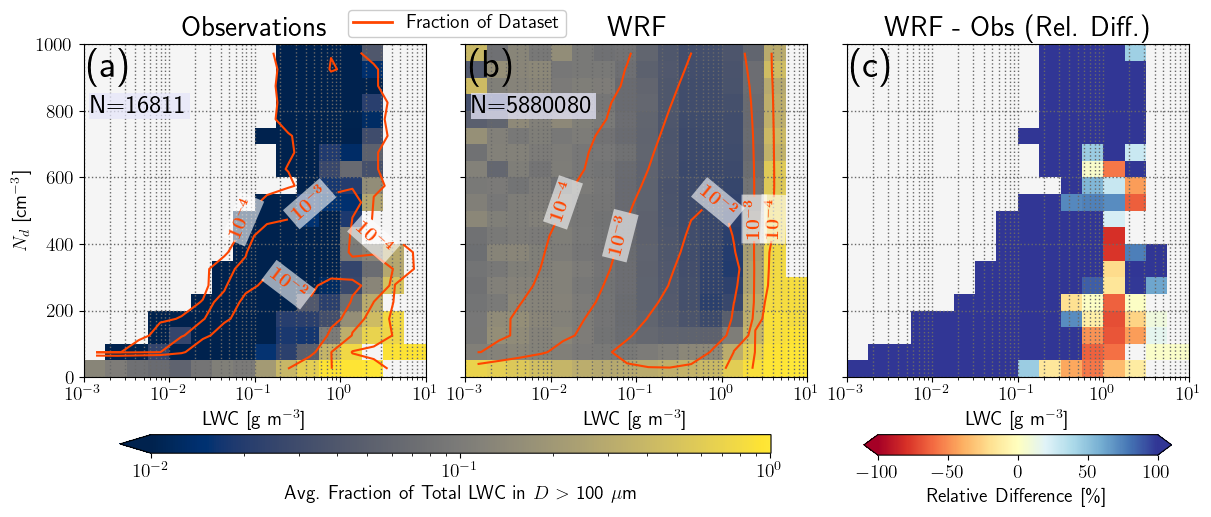

done


In [13]:
fig = plt.figure(figsize=(12, 5), constrained_layout=True) # Increased height slightly for colorbars
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
axlist = [ax1,ax2,ax3]
Fontsize=14
for ax in axlist:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.set_xlabel('LWC [g m$^{-3}$]',fontsize=Fontsize)
    ax.set_xlim(1.e-3,1.e1)
    ax.set_xscale('log')
    
ax1.set_ylabel('$N_{d}$ [cm$^{-3}$]',fontsize=Fontsize)

ax1.set_title("Observations",fontsize=Fontsize*1.5)
ax2.set_title('WRF',fontsize=Fontsize*1.5)
ax3.set_title('WRF - Obs (Rel. Diff.)',fontsize=Fontsize*1.5)
    
ax1.set_ylim(0,1000)
ax2.set_ylim(0,1000)
ax3.set_ylim(0,1000)
for ax in axlist[1:]:
    ax.set_yticklabels([])

#cmap = mpl.colormaps.get_cmap('inferno').copy()
cmap = mpl.colormaps.get_cmap('cividis').copy()

vmin = 1.e-2
vmax = 1.
inc = 0.05
z_bins = np.arange(vmin,vmax+inc,inc) # um
# Custom formatter function to display labels in scientific notation
#def fmt(x):
#    return f'$10^{{{int(np.log10(x))}}}$'
def fmt(x):
    return f'$\\mathbf{{10^{{{int(np.log10(x))}}}}}$'
#c_color = 'mediumvioletred'
c_color = 'orangered'
#c_color = 'tomato'
lab = 'Avg. Fraction of Total LWC in $D$ $>$ 100 $\\mu$m' # Removed newline for horizontal label
extend='min'
c_font = 14
dumy=0.85
#=============================================
# Obs
#=============================================
ax=ax1
samp_size = len(obs_dict['total_conc'])
dum = obs_mean_linlog.copy() 
dum[dum < vmin] = vmin
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm1 = ax.pcolormesh(lwc_bins, conc_bins_lin, dum.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=1))

cm = ax.contour(lwc_midbins,conc_midbins_lin,obs_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
for label in contour_labels:
    label.set_bbox(dict(facecolor='white', edgecolor='none', alpha=0.6, pad=3))
    label.set_fontweight('bold')
#=============================================
# WRF
#=============================================
ax=ax2
samp_size = len(wrf_dict['N'])
# Use the same colormap and normalization
ax.pcolormesh(lwc_bins, conc_bins_lin, wrf_mean_linlog.T, cmap=cmap, shading='auto', norm=mpl.colors.LogNorm(vmin=z_bins[0], vmax=z_bins[-1]))
ax.text(0.02,dumy,'N='+str(samp_size),transform=ax.transAxes,fontweight='bold',\
                     fontsize=Fontsize*1.35,ha='left',va='top',c='k',bbox=dict(facecolor='lavender', edgecolor='none', alpha=0.75, pad=1))

cm = ax.contour(lwc_midbins,conc_midbins_lin,wrf_frac_linlog.T,levels=[1.e-4,1.e-3,1.e-2,1.e-1],colors=c_color)
# Add contour labels with the custom formatter
contour_labels = ax.clabel(cm, fmt=fmt, inline=True, fontsize=c_font)
for label in contour_labels:
    label.set_bbox(dict(facecolor='white', edgecolor='none', alpha=0.6, pad=3))
    label.set_fontweight('bold')
#=============================================
# Obs - WRF
#=============================================
cmap_diff = mpl.colormaps.get_cmap('RdYlBu').copy()
ax = ax3
dum_obs = obs_mean_linlog.T.copy()
dum_obs[dum_obs == 0.] = 1.e-12
rel_diff = (wrf_mean_linlog.T - dum_obs)/dum_obs*100.
# Store the pcolormesh object, but DO NOT create a colorbar here
pcm3 = ax.pcolormesh(lwc_bins, conc_bins_lin, rel_diff, cmap=cmap_diff, shading='auto', vmin=-100, vmax=100)



#=============================================
# ADD NEW HORIZONTAL COLORBARS AT THE BOTTOM
#=============================================

# Shared colorbar for the first two panels
cbar1 = fig.colorbar(pcm1, ax=[ax1, ax2], orientation='horizontal', location='bottom',
                     pad=0.01, extend=extend, shrink=0.9, aspect=35)
cbar1.ax.tick_params(labelsize=Fontsize)
cbar1.set_label(lab, fontsize=Fontsize) # Use set_label for horizontal colorbars

# Separate colorbar for the third panel
cbar3 = fig.colorbar(pcm3, ax=ax3, orientation='horizontal', location='bottom',
                     pad=0.01, extend='both', shrink=0.9, aspect=15)
cbar3.ax.tick_params(labelsize=Fontsize)
cbar3.set_label('Relative Difference [\\%]', fontsize=Fontsize)


labs = ['(a)','(b)','(c)']
for i,ax in enumerate(axlist):
    ax.text(0.01,0.99,labs[i],fontsize=Fontsize*2.,ha='left',va='top',transform=ax.transAxes)


#plt.suptitle('\\underline{\\textbf{Fraction of total LWC in $D$ $>$ 100 $\\mu$m}}', fontsize=Fontsize*1.5, color='navy')
back_color = 'whitesmoke'
for ax in axlist:
    ax.set_facecolor(back_color)
# Create a custom legend
custom_line = Line2D([0], [0], color=c_color, lw=2)
fig.legend([custom_line], ['Fraction of Dataset'],framealpha=True,bbox_to_anchor=(0.475,1.02),fontsize=Fontsize,bbox_transform=fig.transFigure,borderpad=0.25)

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
#fig_name = f"fig_LWC_Nd_Frac_Joint_Histogram.png"
fig_name = f"fig_LWC_Nd_Frac_Joint_Histogram_CLWCthresh.png"
#plt.savefig(save_path + fig_name, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('done')

## Plot histograms of simulated vs. observed Nd in LWC regimes

In [84]:
#Nd_bins = np.arange(0,1050,50)
Nd_bins = np.arange(0,1300,100)
lwc_bins = 10.**np.arange(-3,2,1)
Nd_midbins = np.array([0.5*(Nd_bins[d]+Nd_bins[d+1]) for d in range(len(Nd_bins)-1)])
num_bins = len(Nd_midbins)

obs_Nd = obs_dict['total_conc']
obs_lwc = obs_dict['cloud_lwc']
wrf_Nd = wrf_dict['N']
wrf_lwc = wrf_dict['lwc']
obs_temp = obs_dict['temp']
wrf_temp = wrf_dict['temp']

obs_hist = []
wrf_hist = []

for i in range(len(lwc_bins)-1):
    obs_dumid = np.where( (obs_lwc > lwc_bins[i]) & (obs_lwc <= lwc_bins[i+1]) )
    wrf_dumid = np.where( (wrf_lwc > lwc_bins[i]) & (wrf_lwc <= lwc_bins[i+1]) )

    tmp_obs_Nd = obs_Nd[obs_dumid]
    tmp_wrf_Nd = wrf_Nd[wrf_dumid]

    print(np.min(tmp_obs_Nd),np.max(tmp_obs_Nd))
    print(np.min(tmp_wrf_Nd),np.max(tmp_wrf_Nd))

    tmp_obs_hist = np.histogram(tmp_obs_Nd,Nd_bins,density=True)
    tmp_wrf_hist = np.histogram(tmp_wrf_Nd,Nd_bins,density=True)

    obs_hist.append(tmp_obs_hist[0])
    wrf_hist.append(tmp_wrf_hist[0])

obs_hist = np.array(obs_hist)
wrf_hist = np.array(wrf_hist)

0.007868500106269494 155.24135494232178
2.9840865e-05 2073.8787
0.06356002446593223 463.2716944124113
0.00013830351 2205.6702
0.06709381197611108 1207.6459032371204
0.0004378955 2240.678
0.16227180413167375 1114.5890079815144
0.0053995857 2241.6423


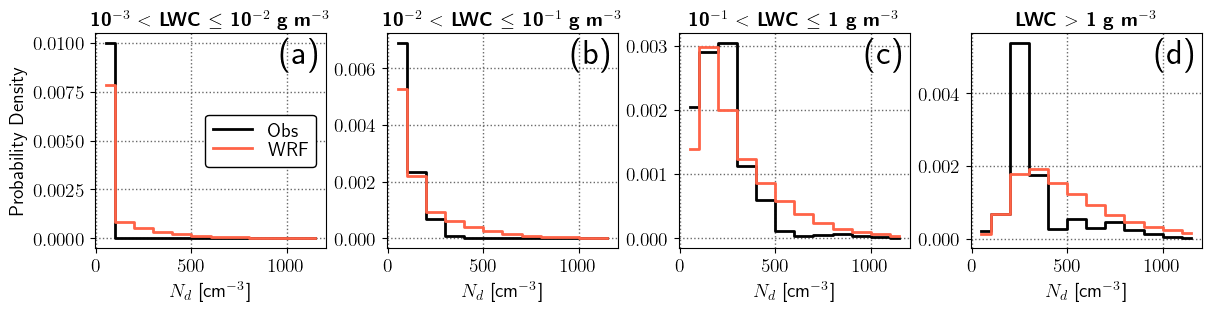

In [100]:
fig,axes = plt.subplots(nrows=1,ncols=4,figsize=(12,3),constrained_layout=True)
axes_flat = np.ndarray.flatten(axes)
Fontsize=14
for ax in axes_flat:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.set_xlabel('$N_{d}$ [cm$^{-3}$]',fontsize=Fontsize)

axes_flat[0].set_ylabel('Probability Density',fontsize=Fontsize)



for i,ax in enumerate(axes_flat):
    ax.step(Nd_midbins,obs_hist[i],lw=2,color='k',label='Obs',where='mid')
    ax.step(Nd_midbins,wrf_hist[i],lw=2,color='tomato',label='WRF',where='mid')
    
titles = [
    '\\textbf{10$^{-3}$ \\textless \ LWC $\\leq$ 10$^{-2}$ g m$^{-3}$}',
    '\\textbf{10$^{-2}$ \\textless \ LWC $\\leq$ 10$^{-1}$ g m$^{-3}$}',
    '\\textbf{10$^{-1}$ \\textless \ LWC $\\leq$ 1 g m$^{-3}$}',
    '\\textbf{LWC \\textgreater \ 1 g m$^{-3}$}',
]


labs = ['(a)','(b)','(c)','(d)']
for i,ax in enumerate(axes_flat):
    ax.text(0.98,0.98,labs[i],fontsize=Fontsize*1.8,transform=ax.transAxes,ha='right',va='top')
    ax.set_title(titles[i],fontsize=Fontsize*1.)

axes_flat[0].legend(loc='center right',fontsize=Fontsize,framealpha=True,edgecolor='k',labelspacing=0.1)

plt.show()
plt.close()

# Plot histogram of altitudes where samples are taken

In [14]:
fig = plt.figure(figsize=(5,4),constrained_layout=True)
ax1 = fig.add_subplot(111)
Figsize=14
axlist = [ax1,ax1]
for ax in axlist:
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylabel('Probability Density',fontsize=Fontsize)
ax1.set_xlabel('Altitude of in-situ Samples [km AMSL]',fontsize=Fontsize)


alt_bins = np.arange(0,5.5,0.5)
ax1.hist(obs_dict['alt']*1.e-3,bins=alt_bins,linewidth=2,color='k',label='Obs',density=True,histtype='step')
ax1.hist(wrf_dict['zamsl']*1.e-3,bins=alt_bins,linewidth=2,color='tomato',label='WRF',density=True,histtype='step')

ax1.legend(loc='upper left',fontsize=Fontsize,framealpha=True,edgecolor='k')


save_path='/global/homes/m/mckenna/figures/jgra_paper/'
fig_name='fig_altitude_PDF.png'
plt.savefig(save_path+fig_name,dpi=200,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


# Plot composite DSDs & MSDs in different LWC-Nd spaces

# Observations

In [15]:
obs_lwc = obs_dict['cloud_lwc'].copy() # g/m^3
obs_N = obs_dict['total_conc'].copy() # cm^-3
obs_dNdD = obs_dict['dNdD'].copy() # count/cm^3/um
obs_dMdD = obs_dict['dMdD'].copy() # g/m^3/um
obs_temp = obs_dict['temp'].copy()
obs_alt = obs_dict['alt'].copy()
obs_time = obs_dict['time'].copy()
obs_dZdD = obs_dNdD*1.e6 # m^-3 um^-1
obs_dZdD = obs_dZdD*((obs_diam*1.e-6)**6.) # m^6 m^-3 um^-1
obs_dZdD = obs_dZdD*1.e18 # mm^6 m^-3 um^-1
# obs_diam is in microns
# obs_dD is in microns
# obs_dlogD is in microns
obs_Z = scipy.integrate.trapezoid(obs_dZdD,obs_diam,axis=1)
obs_dBZ = 10.*np.log10(obs_Z)
print(np.nanmax(obs_dBZ),np.nanmin(obs_dBZ))

63.74911129017814 -64.5717049477971


In [106]:
# --- Recommended, Numerically Stable Calculation ---

# Get data in original units
#obs_dNdD_cm = obs_dict['dNdD'].copy() # count/cm^3/um
#obs_diam_um = obs_dict['obs_diam'].copy() # assuming you have this, otherwise calculate bin centers

# 1. Convert everything to base MKS units for the physical calculation
dNdD_mks = obs_dNdD * 1e12  # Units are now: particles / m³ / m
diam_m = obs_diam * 1e-6    # Units are now: m

# 2. Calculate the reflectivity factor distribution, dZ/dD, in MKS units
# (m⁻³ m⁻¹) * m⁶ = m⁵ m⁻³
dZdD_mks = dNdD_mks * (diam_m**6)

# 3. Integrate with respect to diameter in meters to get total Z in MKS units
# (m⁵ / m³) * m  = m⁶ / m³
Z_mks = scipy.integrate.trapezoid(dZdD_mks, diam_m, axis=1)

# 4. NOW, apply the final conversion to conventional radar units (mm⁶ m⁻³)
# 1 m⁶ = (1000 mm)⁶ = 1e18 mm⁶
obs_Z = Z_mks * 1e18

# 5. Convert to dBZ
# Set a floor to avoid log(-inf) for clear air
Z_floor = 1e-8 
obs_Z[obs_Z < Z_floor] = Z_floor
obs_dBZ = 10 * np.log10(obs_Z)

print(np.nanmax(obs_dBZ), np.nanmin(obs_dBZ))

63.74911176089143 -64.57170469290433


In [107]:
for ii in range(len(obs_N)):
    print('N:',obs_N[ii])
    print('N_int:',scipy.integrate.trapezoid(obs_dNdD[ii,:],obs_diam))
    print('lwc:',obs_lwc[ii])
    print('lwc_int:',scipy.integrate.trapezoid(obs_dMdD[ii,:],obs_diam))
    
    if ii > 10.:
        break
    print('')

N: 0.07372962611360023
N_int: 0.07372962611360023
lwc: 0.020515948531959618
lwc_int: 0.020515945319889952

N: 0.15256300568580627
N_int: 0.15256300568580627
lwc: 0.0013015507109468063
lwc_int: 0.0013015506455770294

N: 0.0731436123334106
N_int: 0.0731436123334106
lwc: 0.002728569885431635
lwc_int: 0.002728569457644755

N: 10.901593923568726
N_int: 10.901593923568726
lwc: 0.0010984068416841682
lwc_int: 0.0010892786734936159

N: 64.76474225521088
N_int: 64.20654231309891
lwc: 0.01720841675310459
lwc_int: 0.017032787820468714

N: 193.32657774461404
N_int: 193.11680734184665
lwc: 0.043482995412316254
lwc_int: 0.04313222064361203

N: 251.1732702255249
N_int: 250.01844549179077
lwc: 0.06245100283579895
lwc_int: 0.06189588463681242

N: 12.141121812164783
N_int: 12.094526804983616
lwc: 0.0031665703554621585
lwc_int: 0.003141615420549208

N: 0.07626659609377384
N_int: 0.07626659609377384
lwc: 0.0016397977933592966
lwc_int: 0.0016397978113522947

N: 5.2646002769470215
N_int: 5.2646002769470215
l

In [108]:
Nd_sep = False
if Nd_sep:
    phase_1_id = np.where( (obs_lwc <= 0.01) & (obs_N < 300.) )[0]
    print(np.shape(phase_1_id))
    phase_2_id = np.where( (obs_lwc > 0.01) & (obs_lwc <= 0.1) & (obs_N < 300.) )[0]
    print(np.shape(phase_2_id))
    phase_3_id = np.where( (obs_lwc > 0.1) & (obs_lwc <= 1.) & (obs_N < 300.) )[0]
    print(np.shape(phase_3_id))
    phase_4_id = np.where( (obs_lwc > 1.) & (obs_N < 300.) )[0]
    print(np.shape(phase_4_id))
    phase_5_id = np.where( (obs_lwc <= 1.) & (obs_N >= 300.) )[0]
    print(np.shape(phase_5_id))
    phase_6_id = np.where( (obs_lwc > 1.) & (obs_N >= 300.) )[0]
    print(np.shape(phase_6_id))
    obs_phase_ids = [phase_1_id,phase_2_id,phase_3_id,phase_4_id,phase_5_id,phase_6_id]
else:
    phase_1_id = np.where(obs_lwc <= 0.01)[0]
    print(np.shape(phase_1_id))
    phase_2_id = np.where( (obs_lwc > 0.01) & (obs_lwc <= 0.1) )[0]
    print(np.shape(phase_2_id))
    phase_3_id = np.where( (obs_lwc > 0.1) & (obs_lwc <= 1.) )[0]
    print(np.shape(phase_3_id))
    phase_4_id = np.where( obs_lwc > 1. )[0]
    print(np.shape(phase_4_id))
    obs_phase_ids = [phase_1_id,phase_2_id,phase_3_id,phase_4_id]


(3278,)
(5813,)
(6923,)
(797,)


In [109]:
obs_phase_dict = {}
for ii in range(len(obs_phase_ids)):
    obs_phase_dict['phase_'+str(int(ii+1))] = {}

    # dNdD
    dum = obs_dNdD[obs_phase_ids[ii],:]#/obs_dD # count/cm^3/um
    obs_phase_dict['phase_'+str(int(ii+1))]['dNdD'] = dum
    dum_mean = np.mean(dum,axis=0) # count/cm^3/um
    dum_mean[dum_mean == 0.] = np.nan
    obs_phase_dict['phase_'+str(int(ii+1))]['mean_dNdD'] = dum_mean

    # dNdlogD
    dum = obs_dNdD[obs_phase_ids[ii],:]*obs_dD/obs_dlogD # count/cm^3
    obs_phase_dict['phase_'+str(int(ii+1))]['dNdlogD'] = dum
    dum_mean = np.mean(dum,axis=0) # count/cm^3/um
    dum_mean[dum_mean == 0.] = np.nan
    obs_phase_dict['phase_'+str(int(ii+1))]['mean_dNdlogD'] = dum_mean

    # dMdD
    dum = obs_dMdD[obs_phase_ids[ii],:]#/obs_dD # g/m^3/um
    obs_phase_dict['phase_'+str(int(ii+1))]['dMdD'] = dum
    dum_mean = np.mean(dum,axis=0)
    dum_mean[dum_mean == 0.] = np.nan
    obs_phase_dict['phase_'+str(int(ii+1))]['mean_dMdD'] = dum_mean # g/cm^3/um
    
    # dMdlogD
    dum = obs_dMdD[obs_phase_ids[ii],:]*obs_dD/obs_dlogD # g/m^3
    obs_phase_dict['phase_'+str(int(ii+1))]['dMdlogD'] = dum
    dum_mean = np.mean(dum,axis=0)
    dum_mean[dum_mean == 0.] = np.nan
    obs_phase_dict['phase_'+str(int(ii+1))]['mean_dMdlogD'] = dum_mean # g/cm^3/um


    # dZdD
    dum = obs_dZdD[obs_phase_ids[ii],:]#/obs_dD # mm^6/m^3/um
    obs_phase_dict['phase_'+str(int(ii+1))]['dZdD'] = dum
    dum_mean = np.mean(dum,axis=0)
    dum_mean[dum_mean == 0.] = np.nan
    obs_phase_dict['phase_'+str(int(ii+1))]['mean_dZdD'] = dum_mean  # mm^6/m^3/um
    
    # dZdlogD
    dum = obs_dZdD[obs_phase_ids[ii],:]*obs_dD/obs_dlogD # mm^6/m^3/um
    obs_phase_dict['phase_'+str(int(ii+1))]['dZdlogD'] = dum
    dum_mean = np.mean(dum,axis=0)
    dum_mean[dum_mean == 0.] = np.nan
    obs_phase_dict['phase_'+str(int(ii+1))]['mean_dZdlogD'] = dum_mean # mm^6/m^3/um
    

In [110]:
# Initialize the main dictionary
obs_phase_dict = {}

# Loop through each of your 6 phase regimes
for ii in range(len(obs_phase_ids)):
    phase_key = f'phase_{int(ii+1)}'
    obs_phase_dict[phase_key] = {}
    
    # Get the indices for the current phase/regime
    current_indices = obs_phase_ids[ii]
    
    print(f"Processing {phase_key} with {len(current_indices)} samples...")

    # --- dN/dD ---
    dNdD_subset = obs_dNdD[current_indices, :]
    N_samples = np.sum(~np.isnan(dNdD_subset), axis=0)
    N_samples[N_samples == 0] = 1 # Avoid division by zero
    
    mean_dNdD = np.nanmean(dNdD_subset, axis=0)
    med_dNdD = np.nanmedian(dNdD_subset, axis=0)
    x10_dNdD = np.nanpercentile(dNdD_subset, 10, axis=0)
    x25_dNdD = np.nanpercentile(dNdD_subset, 25, axis=0)
    x75_dNdD = np.nanpercentile(dNdD_subset, 75, axis=0)
    x90_dNdD = np.nanpercentile(dNdD_subset, 90, axis=0)
    x95_dNdD = np.nanpercentile(dNdD_subset, 95, axis=0)
    x99_dNdD = np.nanpercentile(dNdD_subset, 99, axis=0)
    mean_dNdD[mean_dNdD == 0.] = np.nan
    std_dNdD = np.nanstd(dNdD_subset, axis=0)
    sem_dNdD = std_dNdD / np.sqrt(N_samples)
    
    obs_phase_dict[phase_key]['dNdD'] = dNdD_subset
    obs_phase_dict[phase_key]['mean_dNdD'] = mean_dNdD
    obs_phase_dict[phase_key]['med_dNdD'] = med_dNdD
    obs_phase_dict[phase_key]['x10_dNdD'] = x10_dNdD
    obs_phase_dict[phase_key]['x25_dNdD'] = x25_dNdD
    obs_phase_dict[phase_key]['x75_dNdD'] = x75_dNdD
    obs_phase_dict[phase_key]['x90_dNdD'] = x90_dNdD
    obs_phase_dict[phase_key]['x95_dNdD'] = x95_dNdD
    obs_phase_dict[phase_key]['x99_dNdD'] = x99_dNdD
    obs_phase_dict[phase_key]['std_dNdD'] = std_dNdD
    obs_phase_dict[phase_key]['sem_dNdD'] = sem_dNdD
    obs_phase_dict[phase_key]['dNdD_upper_bound'] = mean_dNdD + sem_dNdD
    obs_phase_dict[phase_key]['dNdD_lower_bound'] = mean_dNdD - sem_dNdD

    # --- dNdlogD ---
    dNdlogD_subset = dNdD_subset * obs_dD / obs_dlogD
    mean_dNdlogD = np.nanmean(dNdlogD_subset, axis=0)
    med_dNdlogD = np.nanmedian(dNdlogD_subset, axis=0)
    x10_dNdlogD = np.nanpercentile(dNdlogD_subset, 10, axis=0)
    x25_dNdlogD = np.nanpercentile(dNdlogD_subset, 25, axis=0)
    x75_dNdlogD = np.nanpercentile(dNdlogD_subset, 75, axis=0)
    x90_dNdlogD = np.nanpercentile(dNdlogD_subset, 90, axis=0)
    x95_dNdlogD = np.nanpercentile(dNdlogD_subset, 95, axis=0)
    x99_dNdlogD = np.nanpercentile(dNdlogD_subset, 99, axis=0)
    mean_dNdlogD[mean_dNdlogD == 0.] = np.nan
    std_dNdlogD = np.nanstd(dNdlogD_subset, axis=0)
    sem_dNdlogD = std_dNdlogD / np.sqrt(N_samples)
    
    obs_phase_dict[phase_key]['dNdlogD'] = dNdlogD_subset
    obs_phase_dict[phase_key]['mean_dNdlogD'] = mean_dNdlogD
    obs_phase_dict[phase_key]['med_dNdlogD'] = med_dNdlogD
    obs_phase_dict[phase_key]['x10_dNdlogD'] = x10_dNdlogD
    obs_phase_dict[phase_key]['x25_dNdlogD'] = x25_dNdlogD
    obs_phase_dict[phase_key]['x75_dNdlogD'] = x75_dNdlogD
    obs_phase_dict[phase_key]['x90_dNdlogD'] = x90_dNdlogD
    obs_phase_dict[phase_key]['x95_dNdlogD'] = x95_dNdlogD
    obs_phase_dict[phase_key]['x99_dNdlogD'] = x99_dNdlogD
    obs_phase_dict[phase_key]['sem_dNdlogD'] = sem_dNdlogD
    obs_phase_dict[phase_key]['dNdlogD_upper_bound'] = mean_dNdlogD + sem_dNdlogD
    obs_phase_dict[phase_key]['dNdlogD_lower_bound'] = mean_dNdlogD - sem_dNdlogD
    
    # --- dMdD ---
    dMdD_subset = obs_dMdD[current_indices, :]
    N_samples_M = np.sum(~np.isnan(dMdD_subset), axis=0)
    N_samples_M[N_samples_M == 0] = 1
    
    mean_dMdD = np.nanmean(dMdD_subset, axis=0)
    med_dMdD = np.nanmedian(dMdD_subset, axis=0)
    x10_dMdD = np.nanpercentile(dMdD_subset, 10, axis=0)
    x25_dMdD = np.nanpercentile(dMdD_subset, 25, axis=0)
    x75_dMdD = np.nanpercentile(dMdD_subset, 75, axis=0)
    x90_dMdD = np.nanpercentile(dMdD_subset, 90, axis=0)
    x95_dMdD = np.nanpercentile(dMdD_subset, 95, axis=0)
    x99_dMdD = np.nanpercentile(dMdD_subset, 99, axis=0)
    mean_dMdD[mean_dMdD == 0.] = np.nan
    std_dMdD = np.nanstd(dMdD_subset, axis=0)
    sem_dMdD = std_dMdD / np.sqrt(N_samples_M)

    obs_phase_dict[phase_key]['dMdD'] = dMdD_subset
    obs_phase_dict[phase_key]['mean_dMdD'] = mean_dMdD
    obs_phase_dict[phase_key]['med_dMdD'] = med_dMdD
    obs_phase_dict[phase_key]['x10_dMdD'] = x10_dMdD
    obs_phase_dict[phase_key]['x25_dMdD'] = x25_dMdD
    obs_phase_dict[phase_key]['x75_dMdD'] = x75_dMdD
    obs_phase_dict[phase_key]['x90_dMdD'] = x90_dMdD
    obs_phase_dict[phase_key]['x95_dMdD'] = x95_dMdD
    obs_phase_dict[phase_key]['x99_dMdD'] = x99_dMdD
    obs_phase_dict[phase_key]['std_dMdD'] = std_dMdD
    obs_phase_dict[phase_key]['sem_dMdD'] = sem_dMdD
    obs_phase_dict[phase_key]['dMdD_upper_bound'] = mean_dMdD + sem_dMdD
    obs_phase_dict[phase_key]['dMdD_lower_bound'] = mean_dMdD - sem_dMdD
    
    # --- dMdlogD ---
    dMdlogD_subset = dMdD_subset * obs_dD / obs_dlogD
    mean_dMdlogD = np.nanmean(dMdlogD_subset, axis=0)
    med_dMdlogD = np.nanmedian(dMdlogD_subset, axis=0)
    x10_dMdlogD = np.nanpercentile(dMdlogD_subset, 10, axis=0)
    x25_dMdlogD = np.nanpercentile(dMdlogD_subset, 25, axis=0)
    x75_dMdlogD = np.nanpercentile(dMdlogD_subset, 75, axis=0)
    x90_dMdlogD = np.nanpercentile(dMdlogD_subset, 90, axis=0)
    x95_dMdlogD = np.nanpercentile(dMdlogD_subset, 95, axis=0)
    x99_dMdlogD = np.nanpercentile(dMdlogD_subset, 99, axis=0)
    mean_dMdlogD[mean_dMdlogD == 0.] = np.nan
    std_dMdlogD = np.nanstd(dMdlogD_subset, axis=0)
    sem_dMdlogD = std_dMdlogD / np.sqrt(N_samples_M)

    obs_phase_dict[phase_key]['dMdlogD'] = dMdlogD_subset
    obs_phase_dict[phase_key]['mean_dMdlogD'] = mean_dMdlogD
    obs_phase_dict[phase_key]['med_dMdlogD'] = med_dMdlogD
    obs_phase_dict[phase_key]['x10_dMdlogD'] = x10_dMdlogD
    obs_phase_dict[phase_key]['x25_dMdlogD'] = x25_dMdlogD
    obs_phase_dict[phase_key]['x75_dMdlogD'] = x75_dMdlogD
    obs_phase_dict[phase_key]['x90_dMdlogD'] = x90_dMdlogD
    obs_phase_dict[phase_key]['x95_dMdlogD'] = x95_dMdlogD
    obs_phase_dict[phase_key]['x99_dMdlogD'] = x99_dMdlogD
    obs_phase_dict[phase_key]['sem_dMdlogD'] = sem_dMdlogD
    obs_phase_dict[phase_key]['dMdlogD_upper_bound'] = mean_dMdlogD + sem_dMdlogD
    obs_phase_dict[phase_key]['dMdlogD_lower_bound'] = mean_dMdlogD - sem_dMdlogD

    # --- dZdD ---
    dZdD_subset = obs_dZdD[current_indices, :]
    N_samples_Z = np.sum(~np.isnan(dZdD_subset), axis=0)
    N_samples_Z[N_samples_Z == 0] = 1

    mean_dZdD = np.nanmean(dZdD_subset, axis=0)
    med_dZdD = np.nanmedian(dZdD_subset, axis=0)
    x10_dZdD = np.nanpercentile(dZdD_subset, 10, axis=0)
    x25_dZdD = np.nanpercentile(dZdD_subset, 25, axis=0)
    x75_dZdD = np.nanpercentile(dZdD_subset, 75, axis=0)
    x90_dZdD = np.nanpercentile(dZdD_subset, 90, axis=0)
    x95_dZdD = np.nanpercentile(dZdD_subset, 95, axis=0)
    x99_dZdD = np.nanpercentile(dZdD_subset, 99, axis=0)
    mean_dZdD[mean_dZdD == 0.] = np.nan
    std_dZdD = np.nanstd(dZdD_subset, axis=0)
    sem_dZdD = std_dZdD / np.sqrt(N_samples_Z)

    obs_phase_dict[phase_key]['dZdD'] = dZdD_subset
    obs_phase_dict[phase_key]['mean_dZdD'] = mean_dZdD
    obs_phase_dict[phase_key]['med_dZdD'] = med_dZdD
    obs_phase_dict[phase_key]['x10_dZdD'] = x10_dZdD
    obs_phase_dict[phase_key]['x25_dZdD'] = x25_dZdD
    obs_phase_dict[phase_key]['x75_dZdD'] = x75_dZdD
    obs_phase_dict[phase_key]['x90_dZdD'] = x90_dZdD
    obs_phase_dict[phase_key]['x95_dZdD'] = x95_dZdD
    obs_phase_dict[phase_key]['x99_dZdD'] = x99_dZdD
    obs_phase_dict[phase_key]['std_dZdD'] = std_dZdD
    obs_phase_dict[phase_key]['sem_dZdD'] = sem_dZdD
    obs_phase_dict[phase_key]['dZdD_upper_bound'] = mean_dZdD + sem_dZdD
    obs_phase_dict[phase_key]['dZdD_lower_bound'] = mean_dZdD - sem_dZdD

    # --- dZdlogD ---
    dZdlogD_subset = dZdD_subset * obs_dD / obs_dlogD
    mean_dZdlogD = np.nanmean(dZdlogD_subset, axis=0)
    med_dZdlogD = np.nanmedian(dZdlogD_subset, axis=0)
    x10_dZdlogD = np.nanpercentile(dZdlogD_subset, 10, axis=0)
    x25_dZdlogD = np.nanpercentile(dZdlogD_subset, 25, axis=0)
    x75_dZdlogD = np.nanpercentile(dZdlogD_subset, 75, axis=0)
    x90_dZdlogD = np.nanpercentile(dZdlogD_subset, 90, axis=0)
    x95_dZdlogD = np.nanpercentile(dZdlogD_subset, 95, axis=0)
    x99_dZdlogD = np.nanpercentile(dZdlogD_subset, 99, axis=0)
    mean_dZdlogD[mean_dZdlogD == 0.] = np.nan
    std_dZdlogD = np.nanstd(dZdlogD_subset, axis=0)
    sem_dZdlogD = std_dZdlogD / np.sqrt(N_samples_Z)
    
    obs_phase_dict[phase_key]['dZdlogD'] = dZdlogD_subset
    obs_phase_dict[phase_key]['mean_dZdlogD'] = mean_dZdlogD
    obs_phase_dict[phase_key]['med_dZdlogD'] = med_dZdlogD
    obs_phase_dict[phase_key]['x10_dZdlogD'] = x10_dZdlogD
    obs_phase_dict[phase_key]['x25_dZdlogD'] = x25_dZdlogD
    obs_phase_dict[phase_key]['x75_dZdlogD'] = x75_dZdlogD
    obs_phase_dict[phase_key]['x90_dZdlogD'] = x90_dZdlogD
    obs_phase_dict[phase_key]['x95_dZdlogD'] = x95_dZdlogD
    obs_phase_dict[phase_key]['x99_dZdlogD'] = x90_dZdlogD
    obs_phase_dict[phase_key]['sem_dZdlogD'] = sem_dZdlogD
    obs_phase_dict[phase_key]['dZdlogD_upper_bound'] = mean_dZdlogD + sem_dZdlogD
    obs_phase_dict[phase_key]['dZdlogD_lower_bound'] = mean_dZdlogD - sem_dZdlogD

print("\n--- Finished processing all phase regimes. ---")
print(f"Example data for 'phase_1': {list(obs_phase_dict['phase_1'].keys())}")

Processing phase_1 with 3278 samples...
Processing phase_2 with 5813 samples...
Processing phase_3 with 6923 samples...
Processing phase_4 with 797 samples...

--- Finished processing all phase regimes. ---
Example data for 'phase_1': ['dNdD', 'mean_dNdD', 'med_dNdD', 'x10_dNdD', 'x25_dNdD', 'x75_dNdD', 'x90_dNdD', 'x95_dNdD', 'x99_dNdD', 'std_dNdD', 'sem_dNdD', 'dNdD_upper_bound', 'dNdD_lower_bound', 'dNdlogD', 'mean_dNdlogD', 'med_dNdlogD', 'x10_dNdlogD', 'x25_dNdlogD', 'x75_dNdlogD', 'x90_dNdlogD', 'x95_dNdlogD', 'x99_dNdlogD', 'sem_dNdlogD', 'dNdlogD_upper_bound', 'dNdlogD_lower_bound', 'dMdD', 'mean_dMdD', 'med_dMdD', 'x10_dMdD', 'x25_dMdD', 'x75_dMdD', 'x90_dMdD', 'x95_dMdD', 'x99_dMdD', 'std_dMdD', 'sem_dMdD', 'dMdD_upper_bound', 'dMdD_lower_bound', 'dMdlogD', 'mean_dMdlogD', 'med_dMdlogD', 'x10_dMdlogD', 'x25_dMdlogD', 'x75_dMdlogD', 'x90_dMdlogD', 'x95_dMdlogD', 'x99_dMdlogD', 'sem_dMdlogD', 'dMdlogD_upper_bound', 'dMdlogD_lower_bound', 'dZdD', 'mean_dZdD', 'med_dZdD', 'x10_dZ

# Construct WRF Size Distributions

In [141]:
for key,val in wrf_dict.items():
    print(key,np.shape(val),np.min(val),np.max(val))

z_agl (582050,) 0.0 3826.678955078125
zamsl (582050,) 662.4927 5103.661
temp (582050,) 0.0 18.054993
RH (582050,) 77.15546 103.53335
lwc (582050,) 0.0010004069 4.205033
D_num (582050,) 5.718291345333109e-07 0.00024251809854461778
D_vol (582050,) 1.3073315713173377e-06 0.0006408778219187443
D_mass (582050,) 1.890696379434401e-06 0.002723286897605582
mmd (582050,) 2e-06 0.0024999999999999996
N (582050,) 5.7344947e-05 2097.7617
q (582050,) 8.006129e-07 0.005006047
rho_air (582050,) 0.78291595 1.2654932
N_0_r (582050,) nan nan
N_0_c (582050,) 9.84393479316781e+25 3.6749608650268706e+111
lambda_r (582050,) nan nan
lambda_c (582050,) 189999.86712758848 18999987.19890461
mu_c (582050,) 2.0 15.0
q_gt_100um (582050,) 6.697044639441715e-185 0.003483426479032151
N_gt_100um (582050,) 1.2410268702640543e-175 971657.6190683683
qr (582050,) 0.0 0.0034836282
qc (582050,) 8.439081e-10 0.004976358
Nr (582050,) 0.0 26.271511
Nc (582050,) 0.0033161663 1999003.4


In [142]:
wrf_lwc = wrf_dict['lwc'].copy() # g/m^3
wrf_N = wrf_dict['N'].copy() # cm^-3
wrf_lambda_r = wrf_dict['lambda_r'].copy() # m^-1
wrf_lambda_c = wrf_dict['lambda_c'].copy() # m^-1
wrf_mu_c = wrf_dict['mu_c'].copy() # -
wrf_N_0_r = wrf_dict['N_0_r'].copy() # m^-4
wrf_N_0_c = wrf_dict['N_0_c'].copy() # m^-4
wrf_qr = wrf_dict['qr'].copy() # kg/kg
wrf_qc = wrf_dict['qc'].copy() # kg/kg
wrf_Nr = wrf_dict['Nr'].copy() # /kg
wrf_Nc = wrf_dict['Nc'].copy() # /kg
wrf_rho_air = wrf_dict['rho_air'].copy() # kg/m^3

rho_w = 1000. # kg/m^3
am = np.pi*rho_w/6. # kg
bm = 3.
mu_r = 0.
# wrf_dN
# wrf_dM

In [143]:
sub_samp = 100000
if Nd_sep:
    phase_1_id = np.where( (wrf_lwc <= 0.01) & (wrf_N < 300.) )[0]
    print(np.shape(phase_1_id))
    phase_1_id = np.random.choice(phase_1_id, size=sub_samp, replace=False)
    
    phase_2_id = np.where( (wrf_lwc > 0.01) & (wrf_lwc <= 0.1) & (wrf_N < 300.) )[0]
    print(np.shape(phase_2_id))
    phase_2_id = np.random.choice(phase_2_id, size=sub_samp, replace=False)
    
    phase_3_id = np.where( (wrf_lwc > 0.1) & (wrf_lwc <= 1.) & (wrf_N < 300.) )[0]
    print(np.shape(phase_3_id))
    phase_3_id = np.random.choice(phase_3_id, size=sub_samp, replace=False)
    
    phase_4_id = np.where( (wrf_lwc > 1.) & (wrf_N < 300.) )[0]
    print(np.shape(phase_4_id))
    phase_4_id = np.random.choice(phase_4_id, size=sub_samp, replace=False)
    
    phase_5_id = np.where( (wrf_lwc <= 1.) & (wrf_N >= 300.) )[0]
    print(np.shape(phase_5_id))
    phase_5_id = np.random.choice(phase_5_id, size=sub_samp, replace=False)
    
    phase_6_id = np.where( (wrf_lwc > 1.) & (wrf_N >= 300.) )[0]
    print(np.shape(phase_6_id))
    phase_6_id = np.random.choice(phase_6_id, size=sub_samp, replace=False)
    
    
    wrf_phase_ids = [phase_1_id,phase_2_id,phase_3_id,phase_4_id,phase_5_id,phase_6_id]
else:
    phase_1_id = np.where( wrf_lwc <= 0.01  )[0]
    print(np.shape(phase_1_id))
    if len(phase_1_id) > sub_samp:
        phase_1_id = np.random.choice(phase_1_id, size=sub_samp, replace=False)
    
    phase_2_id = np.where( (wrf_lwc > 0.01) & (wrf_lwc <= 0.1)  )[0]
    print(np.shape(phase_2_id))
    if len(phase_2_id) > sub_samp:
        phase_2_id = np.random.choice(phase_2_id, size=sub_samp, replace=False)
    
    phase_3_id = np.where( (wrf_lwc > 0.1) & (wrf_lwc <= 1.)  )[0]
    print(np.shape(phase_3_id))
    if len(phase_3_id) > sub_samp:
        phase_3_id = np.random.choice(phase_3_id, size=sub_samp, replace=False)
    
    phase_4_id = np.where( wrf_lwc > 1. )[0]
    print(np.shape(phase_4_id))
    if len(phase_4_id) > sub_samp:
        phase_4_id = np.random.choice(phase_4_id, size=sub_samp, replace=False)
    
    wrf_phase_ids = [phase_1_id,phase_2_id,phase_3_id,phase_4_id]

(6374,)
(59100,)
(455808,)
(60768,)


In [144]:
nD = len(obs_diam)
wrf_phase_dict = {}
for ii in range(len(wrf_phase_ids)):
    wrf_phase_dict['phase_'+str(int(ii+1))] = {}

    phase_id = wrf_phase_ids[ii]
    qr = wrf_qr[phase_id]
    qc = wrf_qc[phase_id]

    rain_id = np.where(qr > 0.)[0]
    cloud_id = np.where(qc > 0.)[0]

    tmp_lambda_r = wrf_lambda_r[phase_id]
    tmp_lambda_c = wrf_lambda_c[phase_id]
    tmp_mu_c = wrf_mu_c[phase_id]
    tmp_N_0_r = wrf_N_0_r[phase_id]
    tmp_N_0_c = wrf_N_0_c[phase_id]

    D = obs_diam[None, :]*1.e-6  # meters shape (1, nD) for broadcasting
    lambda_r = tmp_lambda_r[:, None]
    lambda_c = tmp_lambda_c[:, None]
    mu_c = tmp_mu_c[:, None]  # cloud mu, not used here yet
    N_0_r = tmp_N_0_r[:, None]
    N_0_c = tmp_N_0_c[:, None]
    dNrdD = N_0_r * (D ** mu_r) * np.exp(-lambda_r * D) # m^-4 
    dMrdD = am * D**bm * dNrdD # g/m^4
    dNcdD = N_0_c * (D ** mu_c) * np.exp(-lambda_c * D) # m^-4 
    dMcdD = am * D**bm * dNcdD # g/m^4 

    dNrdD = dNrdD*1.e-6*1.e-6 # cm^-3 um^-1
    dNcdD = dNcdD*1.e-6*1.e-6 # cm^-3 um^-1
    dMrdD = dMrdD*1.e-6*1.e3 # g m^-3 um^-1
    dMcdD = dMcdD*1.e-6*1.e3 # g m^-3 um^-1

    dNrdD[np.isnan(dNrdD)] = 0.
    dNcdD[np.isnan(dNcdD)] = 0.
    dMrdD[np.isnan(dMrdD)] = 0.
    dMcdD[np.isnan(dMcdD)] = 0.
    dNdD = dNrdD + dNcdD
    dMdD = dMrdD + dMcdD
    dZdD = (dNdD*1.e6)*1.e18*(obs_diam*1.e-6)**6. # mm^6 m^-3 um^-1
    dZrdD = (dNrdD*1.e6)*1.e18*(obs_diam*1.e-6)**6. # mm^6 m^-3 um^-1
    dZcdD = (dNcdD*1.e6)*1.e18*(obs_diam*1.e-6)**6. # mm^6 m^-3 um^-1
    

    dNdlogD = dNdD*obs_dD/obs_dlogD # cm^-3
    dNcdlogD = dNcdD*obs_dD/obs_dlogD # cm^-3
    dNrdlogD = dNrdD*obs_dD/obs_dlogD # cm^-3
    dMdlogD = dMdD*obs_dD/obs_dlogD # g m^-3
    dMcdlogD = dMcdD*obs_dD/obs_dlogD # g m^-3
    dMrdlogD = dMrdD*obs_dD/obs_dlogD # g m^-3
    dZdlogD = dZdD*obs_dD/obs_dlogD # mm^6 m^-3
    dZrdlogD = dZrdD*obs_dD/obs_dlogD # mm^6 m^-3
    dZcdlogD = dZcdD*obs_dD/obs_dlogD # mm^6 m^-3
    
    
    wrf_phase_dict['phase_'+str(int(ii+1))]['dNdD'] = dNdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dNcdD'] = dNcdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dNrdD'] = dNrdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dMdD'] = dMdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dMcdD'] = dMcdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dMrdD'] = dMrdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dZdD'] = dZdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dZrdD'] = dZrdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dZcdD'] = dZcdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dNdlogD'] = dNdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dNcdlogD'] = dNcdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dNrdlogD'] = dNrdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dMdlogD'] = dMdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dMcdlogD'] = dMcdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dMrdlogD'] = dMrdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dZdlogD'] = dZdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dZrdlogD'] = dZrdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dZcdlogD'] = dZcdlogD

    mean_dNdD = np.mean(dNdD,axis=0)
    med_dNdD = np.median(dNdD,axis=0)
    x10_dNdD = np.percentile(dNdD,10,axis=0)
    x25_dNdD = np.percentile(dNdD,25,axis=0)
    x75_dNdD = np.percentile(dNdD,75,axis=0)
    x90_dNdD = np.percentile(dNdD,90,axis=0)
    x95_dNdD = np.percentile(dNdD,95,axis=0)
    x99_dNdD = np.percentile(dNdD,99,axis=0)
    N_samples = np.sum(~np.isnan(dNdD), axis=0)
    N_samples[N_samples == 0] = 1 # Avoid division by zero
    mean_dNdD[mean_dNdD == 0.] = np.nan
    std_dNdD = np.nanstd(dNdD, axis=0)
    sem_dNdD = std_dNdD / np.sqrt(N_samples)
    
    mean_dMdD = np.mean(dMdD,axis=0)
    med_dMdD = np.median(dMdD,axis=0)
    x10_dMdD = np.percentile(dMdD,10,axis=0)
    x25_dMdD = np.percentile(dMdD,25,axis=0)
    x75_dMdD = np.percentile(dMdD,75,axis=0)
    x90_dMdD = np.percentile(dMdD,90,axis=0)
    x95_dMdD = np.percentile(dMdD,95,axis=0)
    x99_dMdD = np.percentile(dMdD,99,axis=0)
    N_samples = np.sum(~np.isnan(dMdD), axis=0)
    N_samples[N_samples == 0] = 1 # Avoid division by zero
    mean_dMdD[mean_dMdD == 0.] = np.nan
    std_dMdD = np.nanstd(dMdD, axis=0)
    sem_dMdD = std_dMdD / np.sqrt(N_samples)
    
    mean_dZdD = np.mean(dZdD,axis=0)
    med_dZdD = np.median(dZdD,axis=0)
    x10_dZdD = np.percentile(dZdD,10,axis=0)
    x25_dZdD = np.percentile(dZdD,25,axis=0)
    x75_dZdD = np.percentile(dZdD,75,axis=0)
    x90_dZdD = np.percentile(dZdD,90,axis=0)
    x95_dZdD = np.percentile(dZdD,95,axis=0)
    x99_dZdD = np.percentile(dZdD,99,axis=0)
    N_samples = np.sum(~np.isnan(dZdD), axis=0)
    N_samples[N_samples == 0] = 1 # Avoid division by zero
    mean_dZdD[mean_dZdD == 0.] = np.nan
    std_dZdD = np.nanstd(dZdD, axis=0)
    sem_dZdD = std_dZdD / np.sqrt(N_samples)
    
    mean_dNdlogD = np.mean(dNdlogD,axis=0)
    mean_dNcdlogD = np.mean(dNcdlogD,axis=0)
    mean_dNrdlogD = np.mean(dNrdlogD,axis=0)
    med_dNdlogD = np.median(dNdlogD,axis=0)
    x10_dNdlogD = np.percentile(dNdlogD,10,axis=0)
    x25_dNdlogD = np.percentile(dNdlogD,25,axis=0)
    x75_dNdlogD = np.percentile(dNdlogD,75,axis=0)
    x90_dNdlogD = np.percentile(dNdlogD,90,axis=0)
    x95_dNdlogD = np.percentile(dNdlogD,95,axis=0)
    x99_dNdlogD = np.percentile(dNdlogD,99,axis=0)
    N_samples = np.sum(~np.isnan(dNdlogD), axis=0)
    N_samples[N_samples == 0] = 1 # Avoid division by zero
    mean_dNdlogD[mean_dNdlogD == 0.] = np.nan
    std_dNdlogD = np.nanstd(dNdlogD, axis=0)
    sem_dNdlogD = std_dNdlogD / np.sqrt(N_samples)
    
    mean_dMdlogD = np.mean(dMdlogD,axis=0)
    mean_dMcdlogD = np.mean(dMcdlogD,axis=0)
    mean_dMrdlogD = np.mean(dMrdlogD,axis=0)
    med_dMdlogD = np.median(dMdlogD,axis=0)
    x10_dMdlogD = np.percentile(dMdlogD,10,axis=0)
    x25_dMdlogD = np.percentile(dMdlogD,25,axis=0)
    x75_dMdlogD = np.percentile(dMdlogD,75,axis=0)
    x90_dMdlogD = np.percentile(dMdlogD,90,axis=0)
    x95_dMdlogD = np.percentile(dMdlogD,95,axis=0)
    x99_dMdlogD = np.percentile(dMdlogD,99,axis=0)
    N_samples = np.sum(~np.isnan(dMdlogD), axis=0)
    N_samples[N_samples == 0] = 1 # Avoid division by zero
    mean_dMdlogD[mean_dMdlogD == 0.] = np.nan
    std_dMdlogD = np.nanstd(dMdlogD, axis=0)
    sem_dMdlogD = std_dMdlogD / np.sqrt(N_samples)

    mean_dZdlogD = np.mean(dZdlogD,axis=0)
    med_dZdlogD = np.median(dZdlogD,axis=0)
    x10_dZdlogD = np.percentile(dZdlogD,10,axis=0)
    x25_dZdlogD = np.percentile(dZdlogD,25,axis=0)
    x75_dZdlogD = np.percentile(dZdlogD,75,axis=0)
    x90_dZdlogD = np.percentile(dZdlogD,90,axis=0)
    x95_dZdlogD = np.percentile(dZdlogD,95,axis=0)
    x99_dZdlogD = np.percentile(dZdlogD,99,axis=0)
    N_samples = np.sum(~np.isnan(dZdlogD), axis=0)
    N_samples[N_samples == 0] = 1 # Avoid division by zero
    mean_dZdlogD[mean_dZdlogD == 0.] = np.nan
    std_dZdlogD = np.nanstd(dZdlogD, axis=0)
    sem_dZdlogD = std_dZdlogD / np.sqrt(N_samples)
    
    wrf_phase_dict['phase_'+str(int(ii+1))]['mean_dNdD'] = mean_dNdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['med_dNdD'] = med_dNdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x10_dNdD'] = x10_dNdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x25_dNdD'] = x25_dNdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x75_dNdD'] = x75_dNdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x90_dNdD'] = x90_dNdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x95_dNdD'] = x95_dNdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x99_dNdD'] = x99_dNdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['std_dNdD'] = std_dNdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['sem_dNdD'] = sem_dNdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dNdD_upper_bound'] = mean_dNdD + sem_dNdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dNdD_lower_bound'] = mean_dNdD - sem_dNdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dNdD_upper_bound_std'] = mean_dNdD + std_dNdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dNdD_lower_bound_std'] = mean_dNdD - std_dNdD
    
    wrf_phase_dict['phase_'+str(int(ii+1))]['mean_dMdD'] = mean_dMdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['med_dMdD'] = med_dMdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x10_dMdD'] = x10_dMdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x25_dMdD'] = x25_dMdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x75_dMdD'] = x75_dMdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x90_dMdD'] = x90_dMdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x95_dMdD'] = x95_dMdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x99_dMdD'] = x99_dMdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['std_dMdD'] = std_dMdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['sem_dMdD'] = sem_dMdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dMdD_upper_bound'] = mean_dMdD + sem_dMdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dMdD_lower_bound'] = mean_dMdD - sem_dMdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dMdD_upper_bound_std'] = mean_dMdD + std_dMdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dMdD_lower_bound_std'] = mean_dMdD - std_dMdD
    
    wrf_phase_dict['phase_'+str(int(ii+1))]['mean_dZdD'] = mean_dZdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['med_dZdD'] = med_dZdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x10_dZdD'] = x10_dZdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x25_dZdD'] = x25_dZdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x75_dZdD'] = x75_dZdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x90_dZdD'] = x90_dZdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x95_dZdD'] = x95_dZdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x99_dZdD'] = x99_dZdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['std_dZdD'] = std_dZdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['sem_dZdD'] = sem_dZdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dZdD_upper_bound'] = mean_dZdD + sem_dZdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dZdD_lower_bound'] = mean_dZdD - sem_dZdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dZdD_upper_bound_std'] = mean_dZdD + std_dZdD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dZdD_lower_bound_std'] = mean_dZdD - std_dZdD
    
    wrf_phase_dict['phase_'+str(int(ii+1))]['mean_dNdlogD'] = mean_dNdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['mean_dNcdlogD'] = mean_dNcdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['mean_dNrdlogD'] = mean_dNrdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['med_dNdlogD'] = med_dNdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x10_dNdlogD'] = x10_dNdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x25_dNdlogD'] = x25_dNdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x75_dNdlogD'] = x75_dNdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x90_dNdlogD'] = x90_dNdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x95_dNdlogD'] = x95_dNdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x99_dNdlogD'] = x99_dNdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['std_dNdlogD'] = std_dNdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['sem_dNdlogD'] = sem_dNdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dNdlogD_upper_bound'] = mean_dNdlogD + sem_dNdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dNdlogD_lower_bound'] = mean_dNdlogD - sem_dNdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dNdlogD_upper_bound_std'] = mean_dNdlogD + std_dNdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dNdlogD_lower_bound_std'] = mean_dNdlogD - std_dNdlogD
    
    wrf_phase_dict['phase_'+str(int(ii+1))]['mean_dMdlogD'] = mean_dMdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['mean_dMcdlogD'] = mean_dMcdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['mean_dMrdlogD'] = mean_dMrdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['med_dMdlogD'] = med_dMdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x10_dMdlogD'] = x10_dMdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x25_dMdlogD'] = x25_dMdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x75_dMdlogD'] = x75_dMdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x90_dMdlogD'] = x90_dMdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x95_dMdlogD'] = x95_dMdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x99_dMdlogD'] = x99_dMdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['std_dMdlogD'] = std_dMdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['sem_dMdlogD'] = sem_dMdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dMdlogD_upper_bound'] = mean_dMdlogD + sem_dMdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dMdlogD_lower_bound'] = mean_dMdlogD - sem_dMdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dMdlogD_upper_bound_std'] = mean_dMdlogD + std_dMdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dMdlogD_lower_bound_std'] = mean_dMdlogD - std_dMdlogD
    
    wrf_phase_dict['phase_'+str(int(ii+1))]['mean_dZdlogD'] = mean_dZdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['med_dZdlogD'] = med_dZdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x10_dZdlogD'] = x10_dZdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x25_dZdlogD'] = x25_dZdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x75_dZdlogD'] = x75_dZdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x90_dZdlogD'] = x90_dZdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x95_dZdlogD'] = x95_dZdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['x99_dZdlogD'] = x99_dZdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['std_dZdlogD'] = std_dZdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['sem_dZdlogD'] = sem_dZdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dZdlogD_upper_bound'] = mean_dZdlogD + sem_dZdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dZdlogD_lower_bound'] = mean_dZdlogD - sem_dZdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dZdlogD_upper_bound_std'] = mean_dZdlogD + std_dZdlogD
    wrf_phase_dict['phase_'+str(int(ii+1))]['dZdlogD_lower_bound_std'] = mean_dZdlogD - std_dZdlogD

print('done')

done


In [145]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx], idx
plt.rcParams['text.latex.preamble'] = r'\usepackage{xcolor}'
from matplotlib.patches import Rectangle # You need to import this
from matplotlib.patheffects import withStroke # For text outlines

# Mean + standard error (optional to remove standard error)

In [146]:
# --- THIS IS THE KEY FIX: Interpolate over NaNs for shading ---
def interpolate_nan(y_data):
    """
    Helper to fill NaN gaps in a 1D array using linear interpolation.
    Crucially, it does NOT extrapolate, leaving leading/trailing NaNs in place.
    """
    if np.all(np.isnan(y_data)): # If all data is NaN, return it as is
        return y_data

    # Create a copy to work on, leaving the original unchanged
    y_interp = y_data.copy()

    # Create a boolean mask of valid (non-NaN) data points
    valid_mask = ~np.isnan(y_data)
    
    # Get the x-indices of all points and just the valid points
    all_indices = np.arange(len(y_data))
    valid_indices = all_indices[valid_mask]

    # If there are no valid points or only one, we can't interpolate
    if len(valid_indices) < 2:
        return y_interp

    # Perform the interpolation only on the slice of the array
    # that is between the first and last valid data points.
    
    # Find the index of the first and last valid data points
    first_valid_idx = valid_indices[0]
    last_valid_idx = valid_indices[-1]

    # Perform interpolation only on this "internal" slice
    internal_slice_indices = all_indices[first_valid_idx:last_valid_idx+1]
    internal_slice_valid_indices = np.where(~np.isnan(y_interp[first_valid_idx:last_valid_idx+1]))[0]
    internal_slice_valid_values = y_interp[first_valid_idx:last_valid_idx+1][internal_slice_valid_indices]
    
    # Interpolate the values within this slice
    interpolated_slice = np.interp(
        np.arange(len(internal_slice_indices)), 
        internal_slice_valid_indices, 
        internal_slice_valid_values
    )
    
    # Place the interpolated values back into our copied array
    y_interp[first_valid_idx:last_valid_idx+1] = interpolated_slice

    return y_interp

# --- Helper Function to process and plot data for one source (Obs or WRF) ---
def process_and_plot(axes, data_dict, diam_bins, line_color, marker_color,obs_bool=False,wrf_bool=False):
    """
    Calculates statistics, plots distributions and mean/median diameters.
    Returns integrated values for text annotation.
    """
    axa, axb, axc = axes

    # Extract data for clarity
    dNdlogD = data_dict['mean_dNdlogD']
    dMdlogD = data_dict['mean_dMdlogD']
    dZdlogD = data_dict['mean_dZdlogD']
    if obs_bool:
        dNdlogD_upper_bound = data_dict['dNdlogD_upper_bound']
        dNdlogD_lower_bound = data_dict['dNdlogD_lower_bound']
        dMdlogD_upper_bound = data_dict['dMdlogD_upper_bound']
        dMdlogD_lower_bound = data_dict['dMdlogD_lower_bound']
        dZdlogD_upper_bound = data_dict['dZdlogD_upper_bound']
        dZdlogD_lower_bound = data_dict['dZdlogD_lower_bound']

        dNdlogD_upper_bound = interpolate_nan(dNdlogD_upper_bound)
        dNdlogD_lower_bound = interpolate_nan(dNdlogD_lower_bound)
        dMdlogD_upper_bound = interpolate_nan(dMdlogD_upper_bound)
        dMdlogD_lower_bound = interpolate_nan(dMdlogD_lower_bound)
        dZdlogD_upper_bound = interpolate_nan(dZdlogD_upper_bound)
        dZdlogD_lower_bound = interpolate_nan(dZdlogD_lower_bound)     
    if wrf_bool:
        if False:
            dNdlogD_upper_bound = data_dict['dNdlogD_upper_bound_std']
            dNdlogD_lower_bound = data_dict['dNdlogD_lower_bound_std']
            dMdlogD_upper_bound = data_dict['dMdlogD_upper_bound_std']
            dMdlogD_lower_bound = data_dict['dMdlogD_lower_bound_std']
            dZdlogD_upper_bound = data_dict['dZdlogD_upper_bound_std']
            dZdlogD_lower_bound = data_dict['dZdlogD_lower_bound_std']
        if True:
            dNdlogD_upper_bound = data_dict['dNdlogD_upper_bound']
            dNdlogD_lower_bound = data_dict['dNdlogD_lower_bound']
            dMdlogD_upper_bound = data_dict['dMdlogD_upper_bound']
            dMdlogD_lower_bound = data_dict['dMdlogD_lower_bound']
            dZdlogD_upper_bound = data_dict['dZdlogD_upper_bound']
            dZdlogD_lower_bound = data_dict['dZdlogD_lower_bound']
            
        dNdlogD_upper_bound = interpolate_nan(dNdlogD_upper_bound)
        dNdlogD_lower_bound = interpolate_nan(dNdlogD_lower_bound)
        dMdlogD_upper_bound = interpolate_nan(dMdlogD_upper_bound)
        dMdlogD_lower_bound = interpolate_nan(dMdlogD_lower_bound)
        dZdlogD_upper_bound = interpolate_nan(dZdlogD_upper_bound)
        dZdlogD_lower_bound = interpolate_nan(dZdlogD_lower_bound)  
    
    dNdD = data_dict['mean_dNdD'].copy()
    dNdD[np.isnan(dNdD)] = 0.0
    dMdD = data_dict['mean_dMdD'].copy()
    dMdD[np.isnan(dMdD)] = 0.0
    dZdD = data_dict['mean_dZdD'].copy()
    dZdD[np.isnan(dZdD)] = 0.0
    
    # Plot distributions
    axa.step(diam_bins, dNdlogD, lw=2, c=line_color, where='mid')
    if obs_bool:
        axa.fill_between(diam_bins,dNdlogD_lower_bound,dNdlogD_upper_bound,color=line_color,alpha=0.25,step='mid')
    if wrf_bool:
        axa.fill_between(diam_bins,dNdlogD_lower_bound,dNdlogD_upper_bound,color=line_color,alpha=0.25,step='mid')
        
    axb.step(diam_bins, dMdlogD, lw=2, c=line_color, where='mid')
    if obs_bool:
        axb.fill_between(diam_bins,dMdlogD_lower_bound,dMdlogD_upper_bound,color=line_color,alpha=0.25,step='mid')
    if wrf_bool:
        axb.fill_between(diam_bins,dMdlogD_lower_bound,dMdlogD_upper_bound,color=line_color,alpha=0.25,step='mid')
        
    axc.step(diam_bins, dZdlogD, lw=2, c=line_color, where='mid')
    if obs_bool:
        axc.fill_between(diam_bins,dZdlogD_lower_bound,dZdlogD_upper_bound,color=line_color,alpha=0.25,step='mid')
    if wrf_bool:
        axc.fill_between(diam_bins,dZdlogD_lower_bound,dZdlogD_upper_bound,color=line_color,alpha=0.25,step='mid')
        
    # --- Calculate and Plot Diameters ---
    # Number-weighted mean diameter (Dn)
    num_wgt_mean_diam = scipy.integrate.trapezoid(dNdD * diam_bins, diam_bins) / scipy.integrate.trapezoid(dNdD, diam_bins)
    #print(num_wgt_mean_diam)
    _, nearest_id = find_nearest(diam_bins, num_wgt_mean_diam)
    axa.plot(num_wgt_mean_diam, dNdlogD[nearest_id], 'X', ms=12, c=marker_color, mew=1, zorder=1000,mec='k')

    # Mass-weighted mean diameter (Dm)
    mass_wgt_mean_diam = scipy.integrate.trapezoid(dMdD * diam_bins, diam_bins) / scipy.integrate.trapezoid(dMdD, diam_bins)
    #print(mass_wgt_mean_diam)
    _, nearest_id = find_nearest(diam_bins, mass_wgt_mean_diam)
    axb.plot(mass_wgt_mean_diam, dMdlogD[nearest_id], '^', ms=12, c=marker_color, mew=1, zorder=1000,mec='k')

    # Median mass diameter (MMD)
    cum_mass = scipy.integrate.cumulative_trapezoid(dMdD, diam_bins, initial=0)
    cum_mass /= cum_mass[-1]
    median_idx = np.searchsorted(cum_mass, 0.5)
    median_mass_diam = diam_bins[median_idx]
    #print(median_mass_diam)
    axb.plot(median_mass_diam, dMdlogD[median_idx], 's', ms=9, c=marker_color, mew=1, zorder=1000,mec='k')
    
    # --- Calculate Integrated Values ---
    int_num = np.trapz(np.nan_to_num(dNdD), diam_bins)
    int_mass = np.trapz(np.nan_to_num(dMdD), diam_bins)
    int_ref = np.trapz(np.nan_to_num(dZdD), diam_bins)
    int_dbz = 10. * np.log10(int_ref) if int_ref > 0 else -np.inf

    return int_num, int_mass, int_dbz

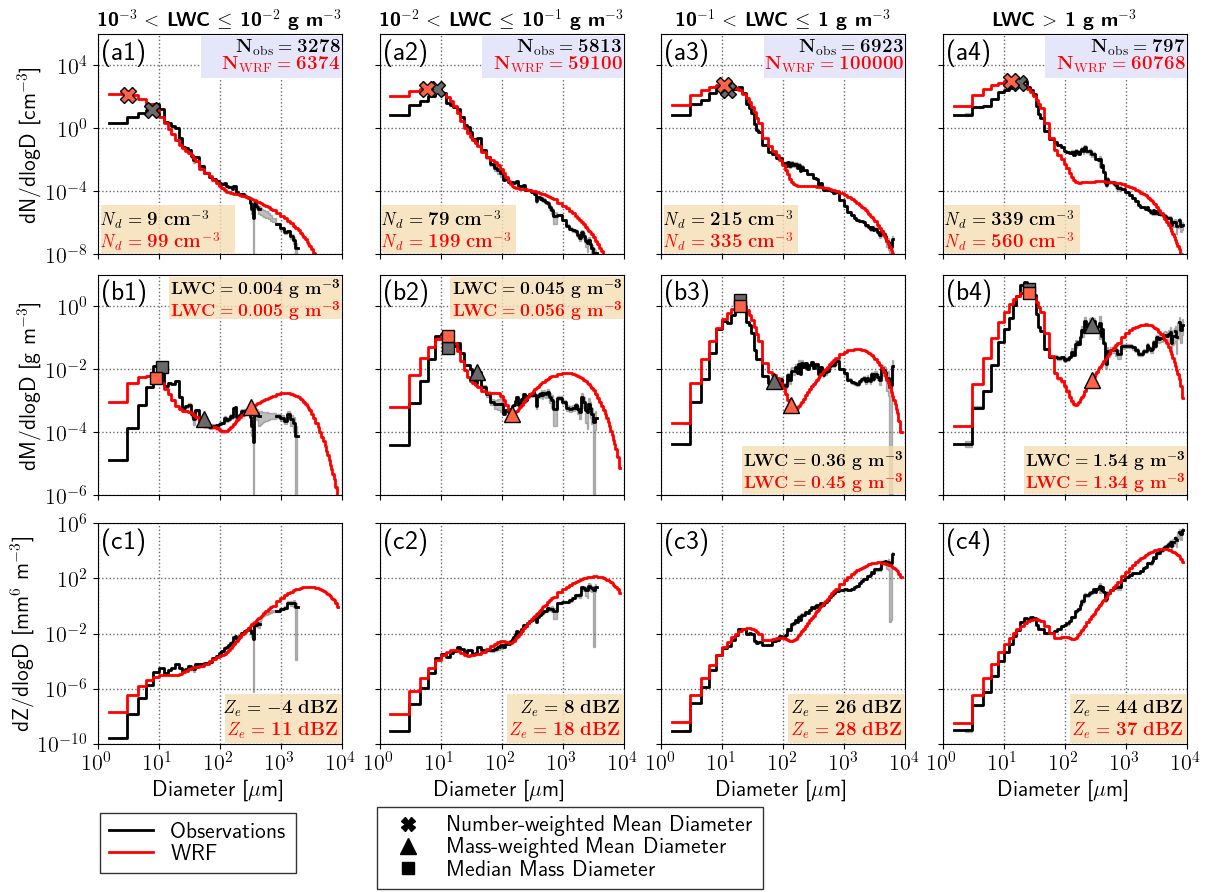

done


In [147]:
# --- Main Plotting Script ---
Fontsize = 16

# 1. Use plt.subplots to create the figure and all axes at once
fig, axs = plt.subplots(3, 4, figsize=(12, 8), constrained_layout=True, sharex=True)

# 2. Configure all axes in a single loop
for ax in axs.flat:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1, 1.e4)
    ax.set_xticks([1,10,1.e2,1.e3,1.e4])

# Set shared labels
for ax in axs[-1,:]:
    ax.set_xlabel('Diameter [$\\mu$m]', fontsize=Fontsize)

# Set y-axis labels for the first column
ylabels = ['dN/dlogD [cm$^{-3}$]', 'dM/dlogD [g m$^{-3}$]', 'dZ/dlogD [mm$^{6}$ m$^{-3}$]']
for i, label in enumerate(ylabels):
    axs[i, 0].set_ylabel(label, fontsize=Fontsize)

# Set y-limits per row
ylims = [(1.e-8, 1.e6), (1.e-6, 1.e1), (1.e-10,1.e6)] # None for the third row, or set specific limits
for i, ylim in enumerate(ylims):
    if ylim:
        for ax in axs[i, :]:
            ax.set_ylim(ylim)

# 3. Use data-driven configuration for titles and formatting
titles = [
    '\\textbf{10$^{-3}$ \\textless \ LWC $\\leq$ 10$^{-2}$ g m$^{-3}$}',
    '\\textbf{10$^{-2}$ \\textless \ LWC $\\leq$ 10$^{-1}$ g m$^{-3}$}',
    '\\textbf{10$^{-1}$ \\textless \ LWC $\\leq$ 1 g m$^{-3}$}',
    '\\textbf{LWC \\textgreater \ 1 g m$^{-3}$}',
]
#title_colors = ['deepskyblue', 'royalblue', 'blue','navy','tomato','maroon']
#title_colors = ['deepskyblue', 'royalblue', 'blue','navy','tomato','maroon']
title_colors = ['k','k','k','k']
float_precisions = [3, 3, 2, 2] # Number of decimal places for LWC text

# 4. Main loop using the helper function
for i, key in enumerate(obs_phase_dict.keys()):
    
    current_axes = axs[:, i] # Get the column of axes for this iteration
    axa, axb, axc = current_axes

    # Process and plot observations
    obs_num, obs_mass, obs_dbz = process_and_plot(
        current_axes, obs_phase_dict[key], obs_diam, line_color='k', marker_color='dimgrey',obs_bool=True,wrf_bool=False,
    )
    
    # Process and plot WRF model data
    wrf_num, wrf_mass, wrf_dbz = process_and_plot(
        current_axes, wrf_phase_dict[key], obs_diam, line_color='red', marker_color='tomato',obs_bool=False,wrf_bool=True,
    )

    # Sample sizes
    fac=0.85
    fac2=0.8
    obs_samp_size = len(obs_phase_dict[key]['dNdD'][:, 0])
    wrf_samp_size = len(wrf_phase_dict[key]['dNdD'][:, 0])
    x_corner,y_corner, box_width, box_height = 0.42, 0.8, 0.58, 0.19  
    rect = Rectangle((x_corner, y_corner), box_width, box_height,facecolor='lavender',alpha=0.99,edgecolor='none',transform=axa.transAxes,zorder=10)# Place it behind the text (which has zorder=10)
    axa.add_patch(rect)
    axa.text(0.99, 0.98, r'$\mathbf{N_{\mathrm{obs}}=' + str(obs_samp_size) + '}$', fontsize=Fontsize*fac, ha='right', va='top', transform=axa.transAxes,zorder=11)
    axa.text(0.99, 0.90, r'$\mathbf{N_{\mathrm{WRF}}=' + str(wrf_samp_size) + '}$', fontsize=Fontsize*fac, ha='right', va='top', transform=axa.transAxes, c='red',zorder=11)

    
    # Integrated Number
    x_corner,y_corner, box_width, box_height = 0.01, 0.005, 0.55, 0.22 
    rect = Rectangle((x_corner, y_corner), box_width, box_height,facecolor='wheat',alpha=0.8,edgecolor='none',transform=axa.transAxes,zorder=10)# Place it behind the text (which has zorder=10)
    axa.add_patch(rect)
    axa.text(0.01, 0.2, f'$\\mathit{{N_d}} = \\mathbf{{{int(obs_num)}}} \\ \\mathrm{{\\mathbf{{cm}}^{{-3}}}}$', fontsize=Fontsize*fac, ha='left', va='top', transform=axa.transAxes,zorder=11)
    axa.text(0.01, 0.1, f'$\\mathit{{N_d}} = \\mathbf{{{int(wrf_num)}}} \\ \\mathrm{{\\mathbf{{cm}}^{{-3}}}}$', fontsize=Fontsize*fac, ha='left', va='top', transform=axa.transAxes, c='red',zorder=11)

    
    # Integrated Mass (LWC)
    precision = float_precisions[i]
    obs_str = f"{obs_mass:.{precision}f}"
    wrf_str = f"{wrf_mass:.{precision}f}"
    # Use different y-positions for columns 2 and 3
    y_pos1, y_pos2 = (0.98, 0.88) if i in [0, 1] else (0.2, 0.1)
    if i in [0,1]:
        x_corner,y_corner, box_width, box_height = 0.29, 0.8, 0.71, 0.19  
    else:
        x_corner,y_corner, box_width, box_height = 0.33, 0.005, 0.67, 0.22 
        
    rect = Rectangle((x_corner, y_corner), box_width, box_height,facecolor='wheat',alpha=0.8,edgecolor='none',transform=axb.transAxes,zorder=10)# Place it behind the text (which has zorder=10)
    axb.add_patch(rect)
    axb.text(0.99, y_pos1, f'$\\mathbf{{LWC={obs_str}\\ g\\ m^{{-3}}}}$', fontsize=Fontsize*fac2, ha='right', va='top', transform=axb.transAxes,zorder=11)
    axb.text(0.99, y_pos2, f'$\\mathbf{{LWC={wrf_str}\\ g\\ m^{{-3}}}}$', fontsize=Fontsize*fac2, ha='right', va='top', transform=axb.transAxes, c='red',zorder=11)

    # Integrated Reflectivity (Ze)
    x_corner,y_corner, box_width, box_height = 0.52, 0.005, 0.48, 0.22 
    rect = Rectangle((x_corner, y_corner), box_width, box_height,facecolor='wheat',alpha=0.8,edgecolor='none',transform=axc.transAxes,zorder=10)# Place it behind the text (which has zorder=10)
    axc.add_patch(rect)
    axc.text(0.99, 0.2, f'$\\mathbf{{\\mathit{{Z_e}} = {int(obs_dbz)}\\ dBZ}}$', fontsize=Fontsize*fac, ha='right', va='top', transform=axc.transAxes,zorder=11)
    axc.text(0.99, 0.1, f'$\\mathbf{{\\mathit{{Z_e}} = {int(wrf_dbz)}\\ dBZ}}$', fontsize=Fontsize*fac, ha='right', va='top', transform=axc.transAxes, c='red',zorder=11)
    
    # Set titles for the top row
    #axs[0, i].set_title(titles[i], fontsize=Fontsize, c=title_colors[i])
    axs[0, i].set_title(titles[i], fontsize=Fontsize*0.9, c='k')
    

# --- Legends (your original code for this was already good) ---
def create_styled_legend(fig, handles, **kwargs):
    legend = fig.legend(handles=handles, **kwargs)
    legend.get_frame().set_boxstyle('square')
    legend.get_frame().set_linewidth(1)
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_facecolor('white')
    return legend

# Legend 1: Lines
line_legend_handles = [
    Line2D([0], [0], color='k', lw=2, label='Observations'),
    Line2D([0], [0], color='red', lw=2, label='WRF')
]
create_styled_legend(fig, line_legend_handles, loc='lower center', bbox_to_anchor=(0.16, -0.09), ncol=1, fontsize=Fontsize, labelspacing=0.1, borderpad=0.1, frameon=True)

# Legend 2: Markers
marker_legend_handles = [
    Line2D([0], [0], ls='None', marker='X', c='k', label='Number-weighted Mean Diameter', ms=10, mew=1),
    Line2D([0], [0], ls='None', marker='^', c='k', label='Mass-weighted Mean Diameter', ms=12, mew=1),
    Line2D([0], [0], ls='None', marker='s', c='k', label='Median Mass Diameter', ms=9, mew=1)
]
create_styled_legend(fig, marker_legend_handles, loc='lower center', bbox_to_anchor=(0.47, -0.11), ncol=1, fontsize=Fontsize, labelspacing=0.1, borderpad=0.1, frameon=True)

if True:
    dum_list = ['a','b','c']
    for j in range(3):
        tmp_axs = axs[j,:]
        for i,ax in enumerate(tmp_axs):
            #ax.text(0.02,0.98,r'\textbf{('+dum_list[j]+str(int(i+1))+')}',fontsize=Fontsize*1.25,transform=ax.transAxes,ha='left',va='top')
            ax.text(0.02,0.98,r'('+dum_list[j]+str(int(i+1))+')',fontsize=Fontsize*1.25,transform=ax.transAxes,ha='left',va='top')

for i in range(3):
    for j in range(1,4):
        axs[i,j].set_yticklabels([])
    
save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
#fig_name = f"fig_Aircraft_SDs.png"
fig_name = f"fig_Aircraft_SDs_CLWCthresh.png"
#plt.savefig(save_path + fig_name, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('done')

# Median plus IQR (or defined range) as shading + individual lines for higher percentages

In [ ]:
# --- Helper Function to process and plot data for one source (Obs or WRF) ---
def process_and_plot(axes, data_dict, diam_bins, line_color, marker_color):
    """
    Calculates statistics, plots distributions and mean/median diameters.
    Returns integrated values for text annotation.
    """
    axa, axb, axc = axes

        
    
    # Extract data for clarity
    dNdlogD = data_dict['mean_dNdlogD']
    med_dNdlogD = data_dict['med_dNdlogD'].copy()
    x10_dNdlogD = data_dict['x10_dNdlogD'].copy()
    x25_dNdlogD = data_dict['x25_dNdlogD'].copy()
    x75_dNdlogD = data_dict['x75_dNdlogD'].copy()
    x90_dNdlogD = data_dict['x90_dNdlogD'].copy()
    x95_dNdlogD = data_dict['x95_dNdlogD'].copy()
    x99_dNdlogD = data_dict['x99_dNdlogD'].copy()
    med_dNdlogD[med_dNdlogD == 0.] = np.nan
    #x10_dNdlogD[x10_dNdlogD == 0.] = np.nan
    #x25_dNdlogD[x25_dNdlogD == 0.] = np.nan
    #x75_dNdlogD[x75_dNdlogD == 0.] = np.nan
    #x90_dNdlogD[x90_dNdlogD == 0.] = np.nan
    x95_dNdlogD[x95_dNdlogD == 0.] = np.nan
    x99_dNdlogD[x99_dNdlogD == 0.] = np.nan

    x10_dNdlogD = interpolate_nan(x10_dNdlogD)
    x25_dNdlogD = interpolate_nan(x25_dNdlogD)
    x75_dNdlogD = interpolate_nan(x75_dNdlogD)
    x90_dNdlogD = interpolate_nan(x90_dNdlogD)
    
    
    dMdlogD = data_dict['mean_dMdlogD']
    med_dMdlogD = data_dict['med_dMdlogD'].copy()
    x10_dMdlogD = data_dict['x10_dMdlogD'].copy()
    x25_dMdlogD = data_dict['x25_dMdlogD'].copy()
    x75_dMdlogD = data_dict['x75_dMdlogD'].copy()
    x90_dMdlogD = data_dict['x90_dMdlogD'].copy()
    x95_dMdlogD = data_dict['x95_dMdlogD'].copy()
    x99_dMdlogD = data_dict['x99_dMdlogD'].copy()
    med_dMdlogD[med_dMdlogD == 0.] = np.nan
    #x10_dMdlogD[x10_dMdlogD == 0.] = np.nan
    #x25_dMdlogD[x25_dMdlogD == 0.] = np.nan
    #x75_dMdlogD[x75_dMdlogD == 0.] = np.nan
    #x90_dMdlogD[x90_dMdlogD == 0.] = np.nan
    x95_dMdlogD[x95_dMdlogD == 0.] = np.nan
    x99_dMdlogD[x99_dMdlogD == 0.] = np.nan

    x10_dMdlogD = interpolate_nan(x10_dMdlogD)
    x25_dMdlogD = interpolate_nan(x25_dMdlogD)
    x75_dMdlogD = interpolate_nan(x75_dMdlogD)
    x90_dMdlogD = interpolate_nan(x90_dMdlogD)
    
    dZdlogD = data_dict['mean_dZdlogD']
    med_dZdlogD = data_dict['med_dZdlogD'].copy()
    x10_dZdlogD = data_dict['x10_dZdlogD'].copy()
    x25_dZdlogD = data_dict['x25_dZdlogD'].copy()
    x75_dZdlogD = data_dict['x75_dZdlogD'].copy()
    x90_dZdlogD = data_dict['x90_dZdlogD'].copy()
    x95_dZdlogD = data_dict['x95_dZdlogD'].copy()
    x99_dZdlogD = data_dict['x99_dZdlogD'].copy()
    med_dZdlogD[med_dZdlogD == 0.] = np.nan
    #x10_dZdlogD[x10_dZdlogD == 0.] = np.nan
    #x25_dZdlogD[x25_dZdlogD == 0.] = np.nan
    #x75_dZdlogD[x75_dZdlogD == 0.] = np.nan
    #x90_dZdlogD[x90_dZdlogD == 0.] = np.nan
    x95_dZdlogD[x95_dZdlogD == 0.] = np.nan
    x99_dZdlogD[x99_dZdlogD == 0.] = np.nan

    x10_dZdlogD = interpolate_nan(x10_dZdlogD)
    x25_dZdlogD = interpolate_nan(x25_dZdlogD)
    x75_dZdlogD = interpolate_nan(x75_dZdlogD)
    x90_dZdlogD = interpolate_nan(x90_dZdlogD)
    
    
    dNdD = data_dict['mean_dNdD'].copy()
    dNdD[np.isnan(dNdD)] = 0.0
    dMdD = data_dict['mean_dMdD'].copy()
    dMdD[np.isnan(dMdD)] = 0.0
    dZdD = data_dict['mean_dZdD'].copy()
    dZdD[np.isnan(dZdD)] = 0.0
    
    # Plot distributions
    axa.step(diam_bins, med_dNdlogD, lw=2, c=line_color, where='mid')
    #axa.step(diam_bins, x10_dNdlogD, lw=1, c=line_color, where='mid')
    #axa.step(diam_bins, x25_dNdlogD, lw=1, c=line_color, where='mid')
    #axa.step(diam_bins, x75_dNdlogD, lw=1, c=line_color, where='mid')
    #axa.step(diam_bins, x90_dNdlogD, lw=1, c=line_color, where='mid')
    axa.step(diam_bins, x95_dNdlogD, lw=1, c=line_color, where='mid')
    axa.step(diam_bins, x99_dNdlogD, lw=1, c=line_color, where='mid',ls='dotted')
    axa.fill_between(diam_bins,x10_dNdlogD,x90_dNdlogD,color=line_color,alpha=0.25,step='mid')
    #axa.fill_between(diam_bins,x25_dNdlogD,x75_dNdlogD,color=line_color,alpha=0.25,step='mid')

    
    axb.step(diam_bins, med_dMdlogD, lw=2, c=line_color, where='mid')
    #axb.step(diam_bins, x10_dMdlogD, lw=1, c=line_color, where='mid')
    #axb.step(diam_bins, x25_dMdlogD, lw=1, c=line_color, where='mid')
    #axb.step(diam_bins, x75_dMdlogD, lw=1, c=line_color, where='mid')
    #axb.step(diam_bins, x90_dMdlogD, lw=1, c=line_color, where='mid')
    axb.step(diam_bins, x95_dMdlogD, lw=1, c=line_color, where='mid')
    axb.step(diam_bins, x99_dMdlogD, lw=1, c=line_color, where='mid',ls='dotted')
    axb.fill_between(diam_bins,x10_dMdlogD,x90_dMdlogD,color=line_color,alpha=0.25,step='mid')
    #axb.fill_between(diam_bins,x25_dMdlogD,x75_dMdlogD,color=line_color,alpha=0.25,step='mid')
    
    axc.step(diam_bins, med_dZdlogD, lw=2, c=line_color, where='mid')
    #axc.step(diam_bins, x10_dZdlogD, lw=1, c=line_color, where='mid')
    #axc.step(diam_bins, x25_dZdlogD, lw=1, c=line_color, where='mid')
    #axc.step(diam_bins, x75_dZdlogD, lw=1, c=line_color, where='mid')
    #axc.step(diam_bins, x90_dZdlogD, lw=1, c=line_color, where='mid')
    axc.step(diam_bins, x95_dZdlogD, lw=1, c=line_color, where='mid')
    axc.step(diam_bins, x99_dZdlogD, lw=1, c=line_color, where='mid',ls='dotted')
    axc.fill_between(diam_bins,x10_dZdlogD,x90_dZdlogD,color=line_color,alpha=0.25,step='mid')
    #axc.fill_between(diam_bins,x25_dZdlogD,x75_dZdlogD,color=line_color,alpha=0.25,step='mid')

    return

In [82]:
# --- Main Plotting Script ---
Fontsize = 16

# 1. Use plt.subplots to create the figure and all axes at once
fig, axs = plt.subplots(3, 4, figsize=(12, 8), constrained_layout=True, sharex=True)

# 2. Configure all axes in a single loop
for ax in axs.flat:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both', lw=0.25, ls='dotted', c='dimgrey')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1, 1.e4)
    ax.set_xticks([1,10,1.e2,1.e3,1.e4])

# Set shared labels
for ax in axs[-1,:]:
    ax.set_xlabel('Diameter [$\\mu$m]', fontsize=Fontsize)

# Set y-axis labels for the first column
ylabels = ['dN/dlogD [cm$^{-3}$]', 'dM/dlogD [g m$^{-3}$]', 'dZ/dlogD [mm$^{6}$ m$^{-3}$]']
for i, label in enumerate(ylabels):
    axs[i, 0].set_ylabel(label, fontsize=Fontsize)

# Set y-limits per row
ylims = [(1.e-8, 1.e6), (1.e-6, 1.e1), (1.e-10,1.e6)] # None for the third row, or set specific limits
#ylims = [(1.e-12, 1.e6), (1.e-10, 1.e1), (1.e-14,1.e6)] # None for the third row, or set specific limits

for i, ylim in enumerate(ylims):
    if ylim:
        for ax in axs[i, :]:
            ax.set_ylim(ylim)

# 3. Use data-driven configuration for titles and formatting
titles = [
    '\\textbf{10$^{-3}$ \\textless \ LWC $\\leq$ 10$^{-2}$ g m$^{-3}$}',
    '\\textbf{10$^{-2}$ \\textless \ LWC $\\leq$ 10$^{-1}$ g m$^{-3}$}',
    '\\textbf{10$^{-1}$ \\textless \ LWC $\\leq$ 1 g m$^{-3}$}',
    '\\textbf{LWC \\textgreater \ 1 g m$^{-3}$}',
]
#title_colors = ['deepskyblue', 'royalblue', 'blue','navy','tomato','maroon']
#title_colors = ['deepskyblue', 'royalblue', 'blue','navy','tomato','maroon']
title_colors = ['k','k','k','k']
float_precisions = [3, 3, 2, 2] # Number of decimal places for LWC text

# 4. Main loop using the helper function
for i, key in enumerate(obs_phase_dict.keys()):
    
    current_axes = axs[:, i] # Get the column of axes for this iteration
    axa, axb, axc = current_axes

    # Process and plot observations
    _ = process_and_plot(
        current_axes, obs_phase_dict[key], obs_diam, line_color='k', marker_color='dimgrey',
    )
    
    # Process and plot WRF model data
    _ = process_and_plot(
        current_axes, wrf_phase_dict[key], obs_diam, line_color='red', marker_color='tomato',
    )

    # Sample sizes
    fac=0.85
    fac2=0.8
    obs_samp_size = len(obs_phase_dict[key]['dNdD'][:, 0])
    wrf_samp_size = len(wrf_phase_dict[key]['dNdD'][:, 0])
    x_corner,y_corner, box_width, box_height = 0.42, 0.8, 0.58, 0.19  
    rect = Rectangle((x_corner, y_corner), box_width, box_height,facecolor='lavender',alpha=0.99,edgecolor='none',transform=axa.transAxes,zorder=10)# Place it behind the text (which has zorder=10)
    axa.add_patch(rect)
    axa.text(0.99, 0.98, r'$\mathbf{N_{\mathrm{obs}}=' + str(obs_samp_size) + '}$', fontsize=Fontsize*fac, ha='right', va='top', transform=axa.transAxes,zorder=11)
    axa.text(0.99, 0.90, r'$\mathbf{N_{\mathrm{WRF}}=' + str(wrf_samp_size) + '}$', fontsize=Fontsize*fac, ha='right', va='top', transform=axa.transAxes, c='red',zorder=11)


    
    # Set titles for the top row
    #axs[0, i].set_title(titles[i], fontsize=Fontsize, c=title_colors[i])
    axs[0, i].set_title(titles[i], fontsize=Fontsize*0.9, c='k')
    

# --- Legends (your original code for this was already good) ---
def create_styled_legend(fig, handles, **kwargs):
    legend = fig.legend(handles=handles, **kwargs)
    legend.get_frame().set_boxstyle('square')
    legend.get_frame().set_linewidth(1)
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_facecolor('white')
    return legend

if False:
    # Legend 1: Lines
    line_legend_handles = [
        Line2D([0], [0], color='k', lw=2, label='Observations'),
        Line2D([0], [0], color='red', lw=2, label='WRF')
    ]
    create_styled_legend(fig, line_legend_handles, loc='lower center', bbox_to_anchor=(0.16, -0.09), ncol=1, fontsize=Fontsize, labelspacing=0.1, borderpad=0.1, frameon=True)
    
    line_legend_handles = [
        Line2D([0], [0], color='k', lw=2, label='Median'),
        Line2D([0], [0], color='k', lw=1, label='10$^{th}$/90$^{th}$ Percentiles'),
        Line2D([0], [0], color='k', lw=0.5, label='95$^{th}$ Percentile'),
        Line2D([0], [0], color='k', lw=0.5, ls='dotted', label='99$^{th}$ Percentile')
    ]
    create_styled_legend(fig, line_legend_handles, loc='lower center', bbox_to_anchor=(0.6, -0.09), ncol=2, fontsize=Fontsize, labelspacing=0.1, borderpad=0.1, frameon=True)


line_legend_handles = [
    Line2D([0], [0], color='k', lw=2, label='Obs Median'),
    Patch(facecolor='k', alpha=0.25, edgecolor=None, label='Obs 10$^{th}$-90$^{th}$ Percentiles'),
    Line2D([0], [0], color='k', lw=1, label='Obs 95$^{th}$ Percentile'),
    Line2D([0], [0], color='k', lw=1, ls='dotted', label='Obs 99$^{th}$ Percentile'),
    Line2D([0], [0], color='red', lw=2, label='WRF Median'),
    Patch(facecolor='red', alpha=0.25, edgecolor=None, label='WRF 10$^{th}$-90$^{th}$ Percentiles'),
    Line2D([0], [0], color='red', lw=1, label='WRF 95$^{th}$ Percentile'),
    Line2D([0], [0], color='red', lw=1, ls='dotted', label='WRF 99$^{th}$ Percentile')
]
create_styled_legend(fig, line_legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=Fontsize, labelspacing=0.1, borderpad=0.1, frameon=True)


dum_list = ['a','b','c']
for j in range(3):
    tmp_axs = axs[j,:]
    for i,ax in enumerate(tmp_axs):
        #ax.text(0.02,0.98,r'\textbf{('+dum_list[j]+str(int(i+1))+')}',fontsize=Fontsize*1.25,transform=ax.transAxes,ha='left',va='top')
        ax.text(0.02,0.98,r'('+dum_list[j]+str(int(i+1))+')',fontsize=Fontsize*1.25,transform=ax.transAxes,ha='left',va='top')

for i in range(3):
    for j in range(1,4):
        axs[i,j].set_yticklabels([])
    
save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
fig_name = f"fig_Aircraft_SDs_percentiles_CLWCthresh.png"
plt.savefig(save_path + fig_name, dpi=300, bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


2026-06-27 11:25:19,520 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/distributed/worker.py", line 1250, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/distributed/utils_comm.py", line 459, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
  File "/global/common/software/m1657/m